# 01. EDA — Batch 1 (학습 데이터)

- 대상: Batch 1 (2017-05-12), 셀 46개
- 사전 준비: 터미널에서 `.venv/bin/python src/preprocess.py 1` 한 번 실행 → `data/cache/`에 캐시 생성
- 각 섹션: **그래프 → 관찰 → 시사점(모델링 전략)** 순서로 채워 넣기

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
plt.rcParams.update({'figure.figsize': (12, 5), 'font.size': 12, 'font.family': 'AppleGothic', 'axes.unicode_minus': False})

df = pd.read_csv('../data/cache/batch1_summary.csv')
z = np.load('../data/cache/batch1_dq.npz')
V = np.linspace(3.5, 2.0, 1000)           # Vdlin (전압 축)
cells = df.drop_duplicates('cell')[['cell', 'cycle_life', 'policy']].reset_index(drop=True)
print(df.shape, '| 셀 수:', len(cells), '| 정책 수:', cells.policy.nunique())
df.head()

(38811, 12) | 셀 수: 46 | 정책 수: 23


,batch,cell,cycle,cycle_life,policy,IR,QCharge,QDischarge,Tavg,Tmax,Tmin,chargetime
0,1,0,1,1190.0,3.6C(80%)-3.6C,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,1,0,2,1190.0,3.6C(80%)-3.6C,0.016742,1.071042,1.070689,31.875011,35.652016,29.566130,13.341250
2,1,0,3,1190.0,3.6C(80%)-3.6C,0.016724,1.071674,1.071900,31.931490,35.692978,29.604385,13.425777
3,1,0,4,1190.0,3.6C(80%)-3.6C,0.016681,1.072304,1.072510,31.932603,35.680588,29.744202,13.425167
4,1,0,5,1190.0,3.6C(80%)-3.6C,0.016662,1.072970,1.073174,31.959322,35.728691,29.644709,13.341442


## Q1. Cycle Life 분포

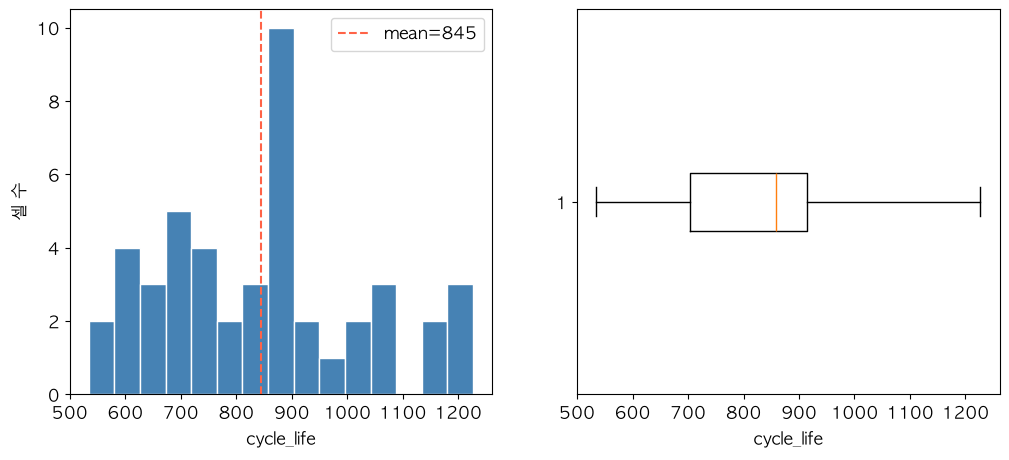

count      46.0
mean      845.0
std       185.0
min       534.0
25%       703.0
50%       858.0
75%       914.0
max      1227.0

장수명(>1000): 10개 (22%)
단수명(<500) : 0개
550 미만     : 1개  (논문 분류 기준 550)
IQR 기준 이상치: Empty DataFrame
Columns: [cell, cycle_life, policy]
Index: []


In [2]:
cl = cells.cycle_life
fig, ax = plt.subplots(1, 2)
ax[0].hist(cl, bins=15, color='steelblue', edgecolor='white')
ax[0].axvline(cl.mean(), color='tomato', ls='--', label=f'mean={cl.mean():.0f}'); ax[0].legend()
ax[0].set_xlabel('cycle_life'); ax[0].set_ylabel('셀 수')
ax[1].boxplot(cl, orientation='horizontal'); ax[1].set_xlabel('cycle_life')
plt.show()

print(cl.describe().round(0).to_string())
print(f"\n장수명(>1000): {(cl>1000).sum()}개 ({(cl>1000).mean():.0%})")
print(f"단수명(<500) : {(cl<500).sum()}개")
print(f"550 미만     : {(cl<550).sum()}개  (논문 분류 기준 550)")
print(f"IQR 기준 이상치:", cells[(cl < cl.quantile(.25)-1.5*(cl.quantile(.75)-cl.quantile(.25))) | (cl > cl.quantile(.75)+1.5*(cl.quantile(.75)-cl.quantile(.25)))].to_string())

**관찰** 
- 46개 셀, 수명 평균 845 (중앙값 858), 범위 534~1227, IQR 703~914. IQR 기준 이상치 셀은 없음.
- 장수명(>1000) 10개(22%), 단수명(<500) 0개, 550 미만 1개(2%).
- 히스토그램은 800~900대에 몰려 있고, 1,200 부근에 소수의 장수명 셀이 떨어져 있음(오른쪽 꼬리).
- 가장 짧은 셀(534)은 가장 빠른 충전 조건(5.4C(80%)-5.4C 계열)이라 '이상치'가 아니라 충전 조건으로 설명됨(Q4).

**시사점**
- 단수명이 없어 분류 기준(550)을 쓰면 짧은 쪽 클래스가 1개뿐 → Batch 1만으로는 분류 학습이 어렵다. **회귀를 선택하는 근거.**
- 1,200대 장수명 셀은 소수라 오차가 크게 날 수 있음 → MAPE와 함께 잔차 분석 필요.
- 이상치 제거는 하지 않는다.

## Q2. 열화 곡선 (방전 용량 QD)

공칭 용량 1.080 Ah | 제거 행 48 (0.12%)


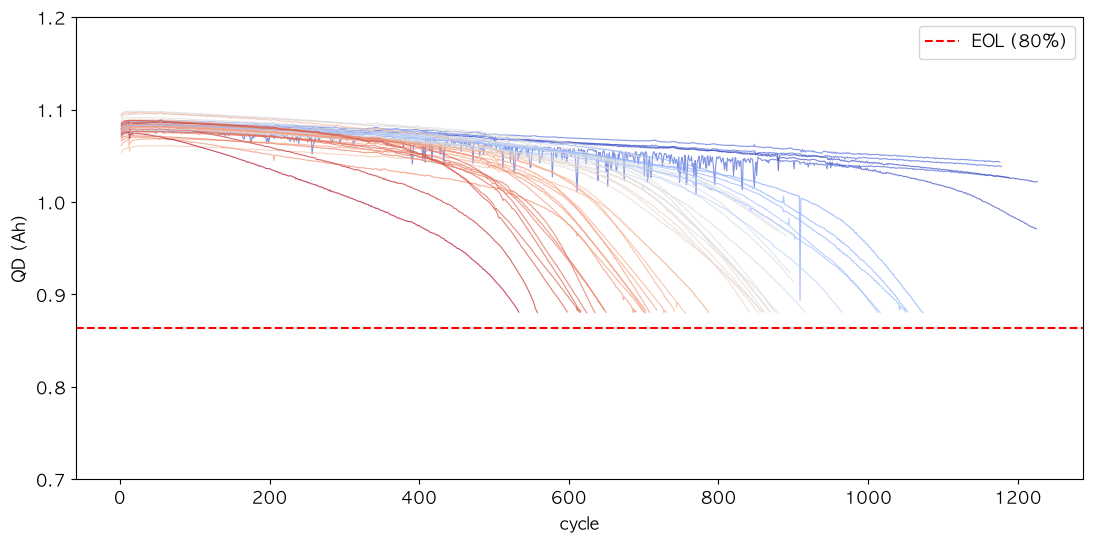

In [3]:
nom = df[df.cycle <= 5].groupby('cell').QDischarge.median().median()
clean = df[df.QDischarge.between(nom*0.8, nom*1.2)]      # 초기 스파이크 제거
print(f'공칭 용량 {nom:.3f} Ah | 제거 행 {len(df)-len(clean)} ({(len(df)-len(clean))/len(df):.2%})')

fig, ax = plt.subplots(figsize=(13, 6))
cmap = plt.cm.coolwarm_r; lo, hi = cells.cycle_life.min(), cells.cycle_life.max()
for c, g in clean.groupby('cell'):
    ax.plot(g.cycle, g.QDischarge, color=cmap((g.cycle_life.iloc[0]-lo)/(hi-lo)), lw=.8, alpha=.7)
ax.axhline(nom*0.8, color='red', ls='--', label='EOL (80%)')
ax.set_ylim(0.7, 1.2); ax.set_xlabel('cycle'); ax.set_ylabel('QD (Ah)'); ax.legend(); plt.show()

knee 탐지 셀: 46/46  | knee/수명 중앙값: 0.71 | 표준편차: 0.09


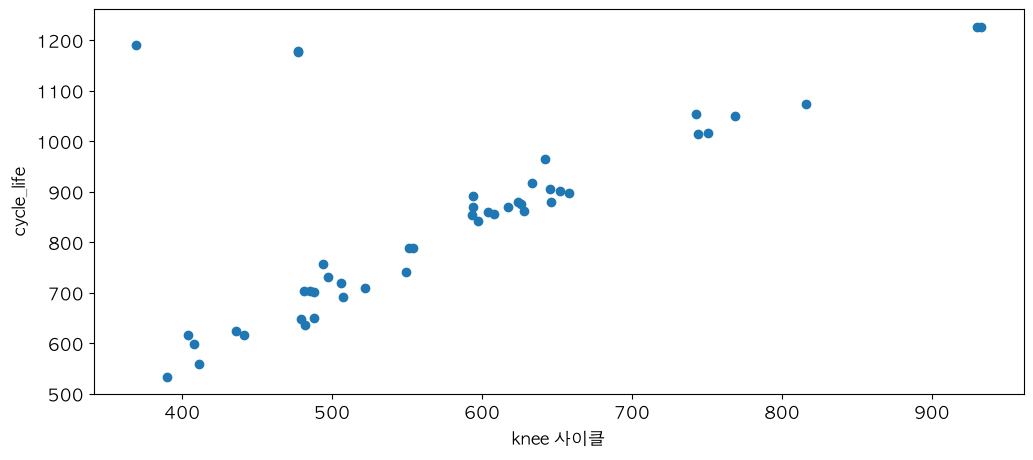

In [4]:
# knee(열화가 꺾이는 지점) 탐지 — Kneedle 방식: 곡선의 시작~끝을 직선으로 이은 뒤, 그 직선에서 가장 멀리 떨어진 점
from scipy.signal import medfilt
def knee(g, k=11):
    q = medfilt(g.QDischarge.values, k)                   # 용량 스파이크 제거
    q = q[k:-k] if len(q) > 3*k else q                    # 필터 가장자리 제외
    x = np.linspace(0, 1, len(q))                         # 사이클을 0~1로 정규화
    q0, qN = np.median(q[:10]), q[-1]
    y = (q - qN) / (q0 - qN)                              # 용량을 1(시작)~0(끝)로 정규화
    return g.cycle.values[k:-k][np.argmax(y - (1 - x))] if len(g) > 3*k else np.nan   # 직선 대비 가장 위로 볼록한 지점

kn = clean.groupby('cell').apply(knee).rename('knee')
k = cells.merge(kn, left_on='cell', right_index=True)
k['knee_ratio'] = k.knee / k.cycle_life
print(f"knee 탐지 셀: {k.knee.notna().sum()}/{len(k)}  | knee/수명 중앙값: {k.knee_ratio.median():.2f} | 표준편차: {k.knee_ratio.std():.2f}")
plt.scatter(k.knee, k.cycle_life); plt.xlabel('knee 사이클'); plt.ylabel('cycle_life'); plt.show()

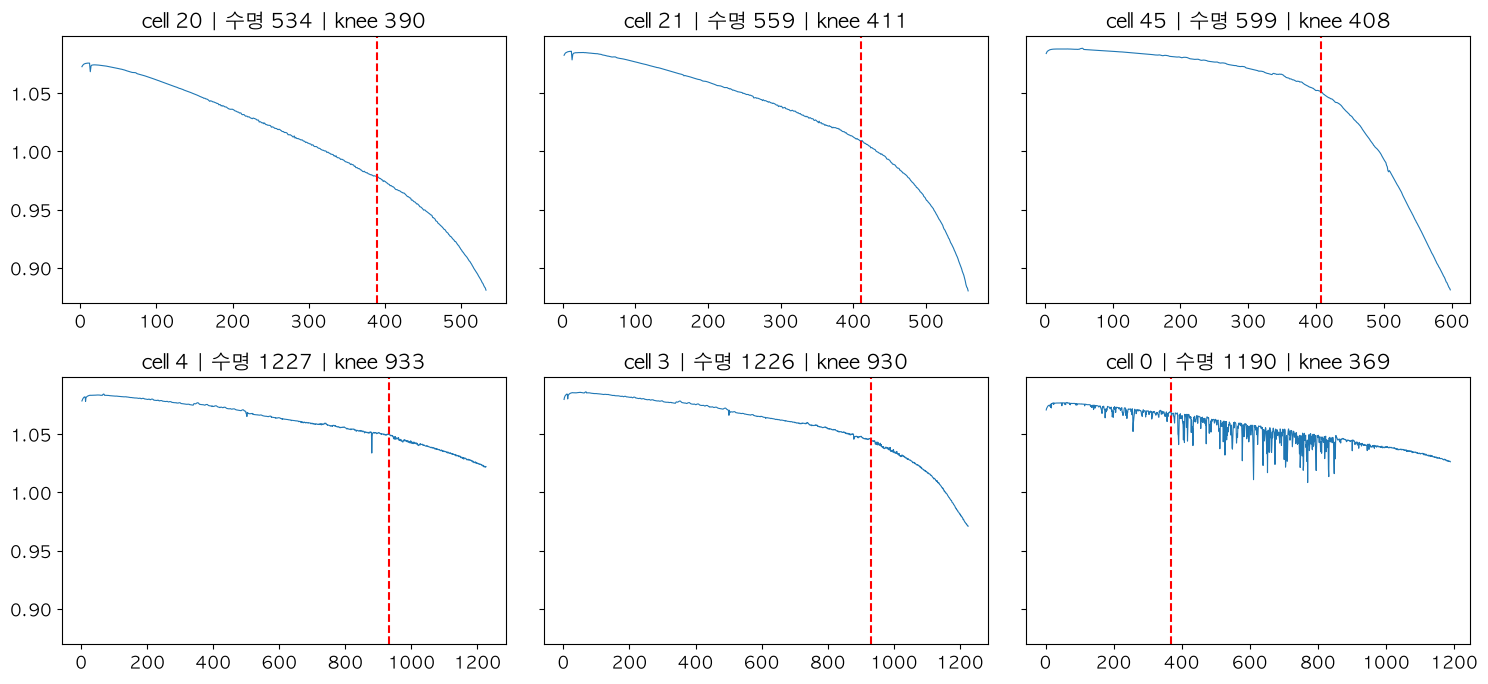

In [5]:
# 육안 검증: 장수명/단수명 셀 각 3개에 knee(빨간 점) 표시
pick = list(k.nsmallest(3, 'cycle_life').cell) + list(k.nlargest(3, 'cycle_life').cell)
fig, axs = plt.subplots(2, 3, figsize=(15, 7), sharey=True)
for a, c_ in zip(axs.flat, pick):
    g_ = clean[clean.cell == c_]; kc = k.set_index('cell').knee[c_]
    a.plot(g_.cycle, g_.QDischarge, lw=.8); a.axvline(kc, color='red', ls='--'); a.set_title(f'cell {c_} | 수명 {g_.cycle_life.iloc[0]:.0f} | knee {kc:.0f}')
plt.tight_layout(); plt.show()

**관찰**
- 모든 셀이 공칭 1.08Ah 부근(1.06~1.10)에서 시작하고 초기 100 사이클 구간은 선들이 거의 겹침.
- 열화는 일정하지 않고 **가속**됨: 완만하게 줄다가 후반에 가파르게 하락. 단수명 셀(빨강)은 **200~300 사이클부터** 기울기가 커지고(가장 짧은 cell 20만 처음부터 내려감), 장수명 셀(파랑)은 1.0Ah 이상을 오래 유지.
- 일부 장수명 셀(예: cell 0)에서 **약 400~900 사이클**에 용량 스파이크(노이즈)가 많음.
- knee(Kneedle: 시작~끝 직선에서 가장 멀리 떨어진 점)는 수명의 약 71%(표준편차 0.09) 지점이고, knee 위치와 수명은 대부분 직선 관계. 단 노이즈가 심한 셀(예: cell 0)은 knee가 369로 일찍 잡히는 실패 사례가 있고, 산점도에서 **knee가 일찍 잡힌 셀 3개**(수명 1,180~1,190인데 knee 370~480)가 직선에서 벗어남.

**시사점**
- 초기 100 사이클에서는 용량 곡선(QD)이 셀마다 거의 겹쳐서 QD만으로는 구분하기 어렵다 → **ΔQ(V) 같은 곡선 형태 feature 필요.**
- 스파이크는 평균 대신 중앙값/구간 요약으로 완화.
- knee는 EOL을 기준으로 정규화하므로 수명과의 직선 관계가 일부 **구조적 착시**이고, 탐지 실패 사례도 있음. 또 knee는 수명의 70% 지점(약 360~930 사이클)에서 나타나 초기 100 사이클만 보는 예측 시점에는 알 수 없음 → **feature로 쓰지 않고 EDA 설명용으로만 사용.**


## Q3. ΔQ(V) 곡선 (사이클 100 − 사이클 10)

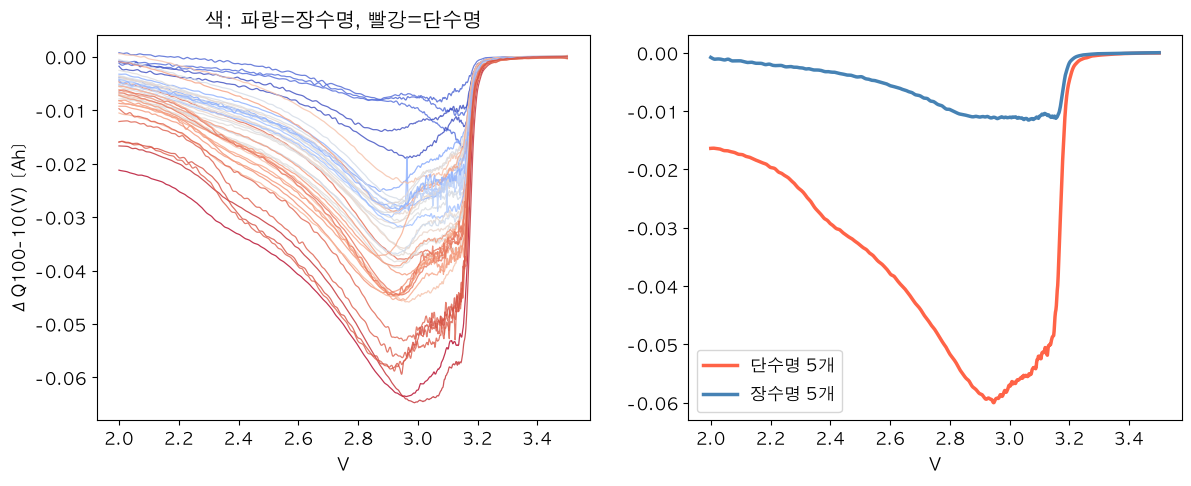

In [6]:
dq = z['q100'] - z['q10']                      # (46, 1000)
life = cells.cycle_life.values
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
for i in range(len(dq)):
    ax[0].plot(V, dq[i], color=cmap((life[i]-lo)/(hi-lo)), lw=.9, alpha=.8)
ax[0].set_xlabel('V'); ax[0].set_ylabel('ΔQ100-10(V) [Ah]'); ax[0].set_title('색: 파랑=장수명, 빨강=단수명')

order = np.argsort(life)
for name, idx, col in [('단수명 5개', order[:5], 'tomato'), ('장수명 5개', order[-5:], 'steelblue')]:
    ax[1].plot(V, dq[idx].mean(0), color=col, lw=2.5, label=name)
ax[1].set_xlabel('V'); ax[1].legend(); plt.show()

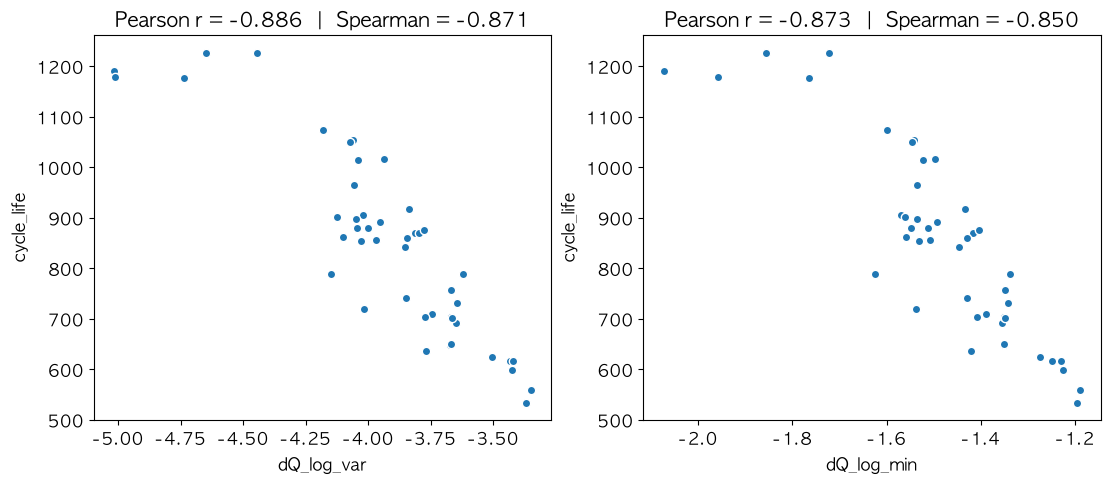

In [7]:
# 곡선 → 숫자 하나로: 논문의 핵심 feature = log10(|분산|), log10(|최솟값|)
feat = pd.DataFrame({'cell': cells.cell, 'cycle_life': life,
                     'dQ_log_var': np.log10(np.abs(np.nanvar(dq, axis=1))),
                     'dQ_log_min': np.log10(np.abs(np.nanmin(dq, axis=1)))})
fig, ax = plt.subplots(1, 2, figsize=(13, 5))
for a, c in zip(ax, ['dQ_log_var', 'dQ_log_min']):
    a.scatter(feat[c], feat.cycle_life, edgecolors='white'); a.set_xlabel(c); a.set_ylabel('cycle_life')
    a.set_title(f"Pearson r = {feat[c].corr(feat.cycle_life):.3f}  |  Spearman = {feat[c].corr(feat.cycle_life, method='spearman'):.3f}")
plt.show()

**관찰**
- 모든 셀의 ΔQ(V)는 3.2V 이상에서 0으로 수렴함. 단수명 셀은 **약 2.9~3.0V**에서 가장 깊고, 장수명 셀은 2.9~3.1V에서 평평하게 얕음.
- **단수명 셀은 곡선이 깊고(5개 평균 최소 약 −0.06Ah), 장수명 셀은 얕음(5개 평균 약 −0.01Ah).** 개별 셀 최소는 −0.065까지 내려감.
- 곡선을 숫자 하나로 요약하면 log10(분산)과 수명의 상관이 r=−0.886(Spearman −0.871), log10(최솟값)은 r=−0.873.
- 산점도는 대체로 선형이지만, 장수명(≥1,100) 5셀은 dQ_log_var가 −5.0~−4.4로 퍼져 있는데 수명은 1,177~1,227로 비슷해 이 구간에서 기울기가 완만해짐(포화). 이 5셀을 제외하면 r=−0.835(Spearman −0.821)로 약해지지만 여전히 강함.

**시사점**
- 곡선의 깊이 = 초기 열화 속도 → **100 사이클 안에 수명 신호가 있다.** `dQ_log_var`를 핵심 feature로 채택.
- `dQ_log_var`와 `dQ_log_min`은 r=0.99로 사실상 같은 정보 → 둘 중 하나만 사용.
- log 변환 후 상관이 −0.838(분산 그대로)에서 −0.886으로 높아져 변환을 사용. 장수명 구간의 포화는 남으므로 잔차 분석으로 확인.


## Q4. 충전 조건(C-rate)과 수명

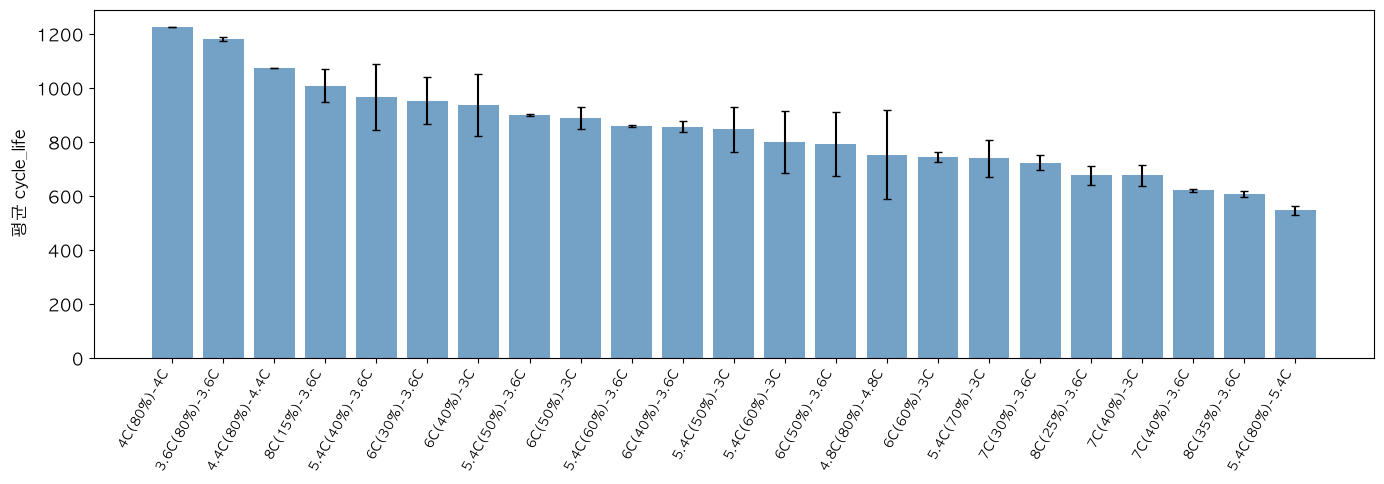

,mean,std,count
policy,,,
4C(80%)-4C,1226.5,0.707107,2
3.6C(80%)-3.6C,1182.0,7.000000,3
4.4C(80%)-4.4C,1074.0,NaN,1
8C(15%)-3.6C,1008.5,60.104076,2
5.4C(40%)-3.6C,966.5,123.743687,2
6C(30%)-3.6C,952.5,86.974134,2
6C(40%)-3C,935.5,115.258405,2
5.4C(50%)-3.6C,899.5,3.535534,2
6C(50%)-3C,888.5,40.305087,2


In [8]:
pl = cells.groupby('policy').cycle_life.agg(['mean', 'std', 'count']).sort_values('mean', ascending=False)
fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(range(len(pl)), pl['mean'], yerr=pl['std'].fillna(0), color='steelblue', alpha=.75, capsize=3)
ax.set_xticks(range(len(pl))); ax.set_xticklabels(pl.index, rotation=60, ha='right', fontsize=9)
ax.set_ylabel('평균 cycle_life'); plt.tight_layout(); plt.show()
pl

c1           -0.580
soc           0.235
c2           -0.096
c_avg        -0.868
cycle_life    1.000


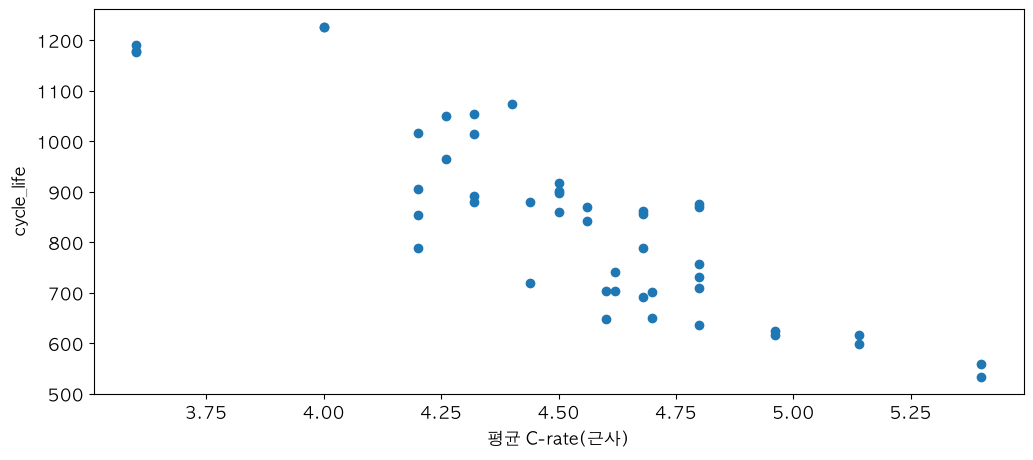

In [9]:
# 정책 문자열 → 숫자: 1단계 C-rate, 전환 SOC(%), 2단계 C-rate, 평균 C-rate(≈ 충전속도)
import re
def parse(p):
    a, soc, b = re.match(r'([\d.]+)C\((\d+)%\)-([\d.]+)C', p).groups()
    a, soc, b = float(a), float(soc), float(b)
    return pd.Series({'c1': a, 'soc': soc, 'c2': b, 'c_avg': a*soc/100 + b*(1-soc/100)})
cells = cells.join(cells.policy.apply(parse))
print(cells[['c1', 'soc', 'c2', 'c_avg', 'cycle_life']].corr()['cycle_life'].round(3).to_string())
plt.scatter(cells.c_avg, cells.cycle_life); plt.xlabel('평균 C-rate(근사)'); plt.ylabel('cycle_life'); plt.show()

c1      -0.075
soc     -0.229
c2      -0.560
c_avg   -0.596
slope    1.000


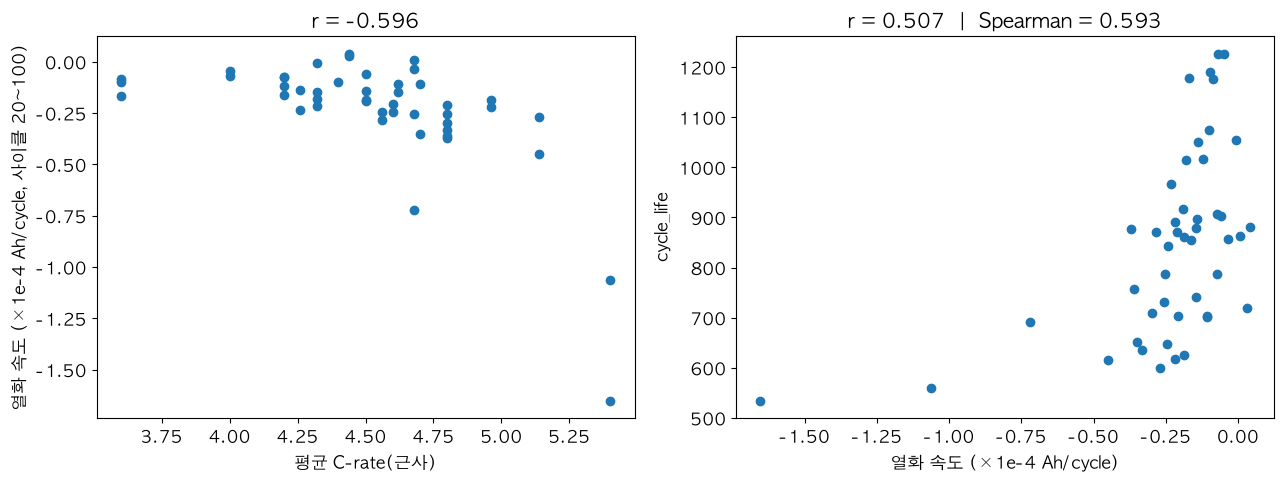

In [10]:
# 충전 속도와 열화 속도의 관계: 열화 속도 = 사이클 20~100 구간의 QD 기울기 (Ah/cycle, 음수일수록 빠르게 열화)
def slope(g): g = g[(g.cycle >= 20) & (g.cycle <= 100)]; return np.polyfit(g.cycle, g.QDischarge, 1)[0]
sl = clean.groupby('cell').apply(slope).rename('slope')
m = cells.merge(sl, left_on='cell', right_index=True)
print(m[['c1', 'soc', 'c2', 'c_avg', 'slope']].corr()['slope'].round(3).to_string())
fig, ax = plt.subplots(1, 2, figsize=(13, 5))
ax[0].scatter(m.c_avg, m.slope * 1e4); ax[0].set_xlabel('평균 C-rate(근사)'); ax[0].set_ylabel('열화 속도 (×1e-4 Ah/cycle, 사이클 20~100)')
ax[0].set_title(f"r = {m.c_avg.corr(m.slope):.3f}")
ax[1].scatter(m.slope * 1e4, m.cycle_life); ax[1].set_xlabel('열화 속도 (×1e-4 Ah/cycle)'); ax[1].set_ylabel('cycle_life')
ax[1].set_title(f"r = {m.slope.corr(m.cycle_life):.3f}  |  Spearman = {m.slope.corr(m.cycle_life, method='spearman'):.3f}")
plt.tight_layout(); plt.show()


**관찰**
- 수명이 가장 긴 정책: 4C(80%)-4C(1227), 3.6C(80%)-3.6C(1182). 가장 짧은 정책: 5.4C(80%)-5.4C(547), 8C(35%)-3.6C(608)(7C(40%)-3.6C 621과 근소한 차이).
- 평균 C-rate(근사)와 수명의 상관 r=−0.87 (1단계 C-rate −0.58, 전환 SOC +0.23, 2단계 C-rate −0.10). 빠르게 충전할수록 수명이 짧아지는 **경향**이 있음. 단 3.6C·4C 정책 셀(왼쪽 위)을 제외하면 r=−0.79(Spearman −0.77)로 약해지고, 같은 평균 C-rate에서도 수명이 200 사이클 넘게 퍼짐(예: 4.80은 636~876, 4.20은 788~1,017).
- 1단계가 같은 8C여도 전환 SOC에 따라 수명이 달라짐(15% 1,008 → 25% 677 → 35% 608). 1단계 속도보다 **얼마나 오래 고속으로 충전하는가**가 중요하며, 평균 C-rate가 1단계 C-rate보다 상관이 큰 이유와 일치.
- **열화 속도**(사이클 20~100의 QD 기울기)와 평균 C-rate의 상관은 r=−0.60(Spearman −0.64)로 수명보다 약함. 대부분 셀의 기울기가 0~−0.4(×1e-4 Ah/cycle)에 몰려 있고, 가장 빠르게 열화하는 3셀(5.4C(80%)-5.4C 2개, 5.4C(70%)-3C 1개)이 상관을 끌어올림(이 3셀 제외 r=−0.51). 2단계 C-rate가 −0.56으로 가장 큼(수명에서는 1단계 −0.58이 컸음).
- 열화 속도와 수명의 상관은 r=+0.51(Spearman +0.59)로 약함. 초기 100 사이클 용량 기울기만으로는 수명을 설명하기 어렵고, ΔQ(V)(r=−0.89)가 훨씬 강함.
- 정책당 셀이 1~3개뿐이라 경향 수준. 같은 정책 안에서도 편차가 큰 경우가 있음(예: 5.4C(40%)-3.6C 표준편차 124, 4.8C(80%)-4.8C 표준편차 165). 대부분 셀이 2개라 표준편차 자체가 불안정.

**시사점**
- 평균 C-rate는 Batch 1에서는 수명과 상관이 크지만(r=−0.87), 학습 정책이 23종뿐이라 **새 정책에 일반화되는지는 Batch 2·3에서 확인이 필요**함.
- 같은 정책 안의 편차는 셀에서 측정한 신호(ΔQ 등)로 보완해야 함.
- 초기 열화 속도(QD 기울기)는 수명과 상관이 약해 feature로 쓰지 않음. ΔQ(V)가 같은 정보를 더 강하게 담고 있음.
- 평균 C-rate는 근사값이므로 해석에 주의.


## Q5. 초기 사이클 feature와 수명의 상관 (초기 100 사이클)

dQ_log_var        -0.886
dQ_log_min        -0.873
c_avg             -0.868
chargetime_mean    0.577
Tavg_mean         -0.482
Tmax_mean         -0.404
QD_slope           0.198
QD_mean            0.193
IR_mean            0.177
QD_std            -0.090


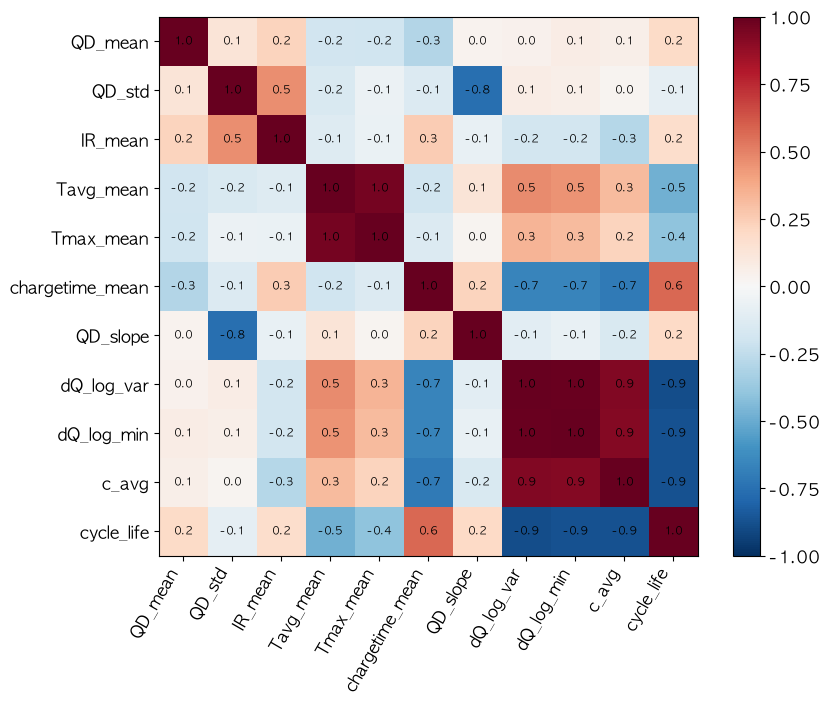

In [11]:
e = df[df.cycle <= 100].groupby('cell')
X = pd.DataFrame({
    'QD_mean': e.QDischarge.mean(), 'QD_std': e.QDischarge.std(),
    'IR_mean': e.IR.mean(), 'Tavg_mean': e.Tavg.mean(), 'Tmax_mean': e.Tmax.mean(),
    'chargetime_mean': e.chargetime.mean()})
X['QD_slope'] = e.apply(lambda g: np.polyfit(g.cycle, g.QDischarge, 1)[0])   # 초기 용량 감소 기울기
X = X.join(feat.set_index('cell')[['dQ_log_var', 'dQ_log_min']]).join(cells.set_index('cell')[['c_avg']])
X['cycle_life'] = cells.set_index('cell').cycle_life
r = X.corr()
print(r.cycle_life.drop('cycle_life').sort_values(key=abs, ascending=False).round(3).to_string())

fig, ax = plt.subplots(figsize=(9, 7)); im = ax.imshow(r, cmap='RdBu_r', vmin=-1, vmax=1); plt.colorbar(im)
ax.set_xticks(range(len(r))); ax.set_xticklabels(r.columns, rotation=60, ha='right'); ax.set_yticks(range(len(r))); ax.set_yticklabels(r.columns)
for i in range(len(r)):
    for j in range(len(r)): ax.text(j, i, f'{r.iloc[i,j]:.1f}', ha='center', va='center', fontsize=8)
plt.show()

In [12]:
# 다중공선성: |r| > 0.9 인 feature 쌍
f = r.drop(index='cycle_life', columns='cycle_life'); pairs = [(a, b, round(f.loc[a, b], 2)) for i, a in enumerate(f.index) for b in f.columns[i+1:] if abs(f.loc[a, b]) > .9]
pairs

[('Tavg_mean', 'Tmax_mean', np.float64(0.96)),
 ('dQ_log_var', 'dQ_log_min', np.float64(0.99)),
 ('dQ_log_var', 'c_avg', np.float64(0.92)),
 ('dQ_log_min', 'c_avg', np.float64(0.92))]

**관찰**
- 수명과 상관이 가장 강한 feature는 dQ_log_var −0.89, dQ_log_min −0.87, 평균 C-rate −0.87로 **비슷한 수준**(46셀에서 −0.886/−0.873/−0.868은 구분이 어려움). 그다음이 chargetime_mean +0.58, Tavg −0.48, Tmax −0.40.
- 초기 용량·내부저항 계열은 약함: QD_slope +0.20, QD_mean +0.19, IR_mean +0.18, QD_std −0.09.
- 다중공선성(|r|>0.9): Tavg–Tmax 0.96, dQ_log_var–dQ_log_min 0.99, dQ_log_var–평균 C-rate 0.92. 이 밖에도 chargetime–dQ/c_avg −0.7, QD_std–QD_slope −0.8로 중간 이상의 상관이 있음.

**시사점**
- `dQ_log_var`를 중심 feature로 사용. 중복 쌍은 한쪽만 선택(Tavg/Tmax 중 하나, dQ 중 하나).
- dQ_log_var와 평균 C-rate가 r=0.92로 겹쳐서 정책 feature를 추가해도 이득이 작을 **가능성이 있음**(Batch 1 교차검증으로 확인).
- feature가 많아지면 상관이 높아 **규제 선형 모델(Elastic Net)이 유리**하고, 비선형 확인용으로 Random Forest/Gradient Boosting을 비교. 단 `dQ_log_var` 1개만 쓸 때는 Elastic Net이 단순 선형 회귀와 거의 같으므로 기준선으로 둠.


---
# Batch 2 · 3 EDA (Batch 1과 비교)

- **목적: Batch 1과 얼마나 다른지 확인.** 모델 학습·feature 선택·튜닝에는 Batch 2/3를 쓰지 않음 (Batch 2는 Day 2 최종 평가 전용, Batch 3는 EDA만)
- 구성: 공통 준비 → **Batch 2 vs Batch 1** → **Batch 3 vs Batch 1**
- 사전 준비: `.venv/bin/python src/preprocess.py 2`, `... 3`

In [13]:
# 공통 준비: 3개 배치 로드 + feature 계산 (이후 섹션에서 재사용)
from scipy.stats import ks_2samp
def load(n):
    d = pd.read_csv(f'../data/cache/batch{n}_summary.csv'); zz = np.load(f'../data/cache/batch{n}_dq.npz')
    c = d.drop_duplicates('cell')[['batch', 'cell', 'cycle_life', 'policy']].reset_index(drop=True)
    dq_ = zz['q100'] - zz['q10']
    c['dQ_log_var'] = np.log10(np.abs(np.nanvar(dq_, axis=1))); c['dQ_log_min'] = np.log10(np.abs(np.nanmin(dq_, axis=1)))
    c['n_cycles'] = d.groupby('cell').cycle.max().values
    return d, c, zz, dq_
B = {n: load(n) for n in (1, 2, 3)}
col = {1: 'steelblue', 2: 'tomato', 3: 'seagreen'}
cb_all = pd.concat([B[n][1] for n in B])
cb = cb_all.dropna(subset=['cycle_life']).copy()            # 수명 없는 셀(NaN)은 분석에서 제외

def parse_safe(p):
    try: return parse(p)
    except Exception: return pd.Series({'c1': np.nan, 'soc': np.nan, 'c2': np.nan, 'c_avg': np.nan})
cb = cb.reset_index(drop=True); cb = cb.join(cb.policy.apply(parse_safe))

def slope(g): g = g[(g.cycle >= 20) & (g.cycle <= 100)]; return np.polyfit(g.cycle, g.QDischarge, 1)[0]
rows = []
for n in B:
    d_ = B[n][0]; d_ = d_[d_.QDischarge.between(0.8, 1.2)]
    c_ = B[n][1].set_index('cell'); c_['slope'] = d_.groupby('cell').apply(slope); c_['knee'] = d_.groupby('cell').apply(knee)
    c_['knee_ratio'] = c_.knee / c_.cycle_life; rows.append(c_.dropna(subset=['cycle_life']))
sk = pd.concat(rows)

def early_feats(d, c):
    e = d[d.cycle <= 100].groupby('cell')
    X_ = pd.DataFrame({'QD_mean': e.QDischarge.mean(), 'IR_mean': e.IR.mean(), 'Tavg_mean': e.Tavg.mean(), 'chargetime_mean': e.chargetime.mean(),
                       'QD_slope': e.apply(lambda g: np.polyfit(g.cycle, g.QDischarge, 1)[0])})
    return X_.join(c.set_index('cell')[['dQ_log_var', 'dQ_log_min', 'cycle_life']]).dropna(subset=['cycle_life'])
corr_b = pd.DataFrame({f'Batch {n}': early_feats(B[n][0], B[n][1]).corr().cycle_life.drop('cycle_life') for n in B})
lo_, hi_ = cb.cycle_life.min(), cb.cycle_life.max()         # 색상 기준(전 배치 공통)

print('[데이터 품질] 배치별 요약')
display(cb_all.groupby('batch').agg(셀수=('cell', 'count'), 수명없음_NaN=('cycle_life', lambda s: s.isna().sum()), 최소사이클수=('n_cycles', 'min'), 정책수=('policy', 'nunique')))
print('수명이 NaN인 셀 = EOL(80%)에 도달하지 못했거나 특수 실험 셀 → 분석에서 제외')
display(cb_all[cb_all.cycle_life.isna()][['batch', 'cell', 'policy', 'n_cycles']])

[데이터 품질] 배치별 요약


,셀수,수명없음_NaN,최소사이클수,정책수
batch,,,,
1,46,0,533,23
2,47,8,101,20
3,46,2,540,8


수명이 NaN인 셀 = EOL(80%)에 도달하지 못했거나 특수 실험 셀 → 분석에서 제외


,batch,cell,policy,n_cycles
22,2,22,VarCharge-2C-100cycles,920
23,2,23,VarCharge-4C-100cycles,1152
35,2,35,VarCharge-6C-100cycles,423
36,2,36,VarCharge-8C-100cycles,280
37,2,37,3.6C(80%)-3.6C(SLOWCYCLE,101
38,2,38,4.8C(80%)-4.8C(SLOWCYCLE,101
39,2,39,3.6C(9%)-5C(SLOWCYCLE,434
40,2,40,5.2C(58%)-4C(SLOWCYCLE,459
23,3,23,4.8C(80%)-4.8C-newstructure,2189
32,3,32,4.8C(80%)-4.8C-newstructure,2237


---
# 🟥 Batch 2 vs Batch 1

> **Batch 2 = Day 2 최종 평가(Test) 데이터.** 아래는 분포 비교용이며, 결과를 보고 feature·모델을 고르지 않는다.

In [14]:
T = 2                                                   # 비교 대상 배치
S = cb[cb.batch.isin([1, T])]
print(f'[핵심 숫자] Batch 1 vs Batch {T}')
display(S.groupby('batch').agg(셀수=('cell', 'count'), 평균수명=('cycle_life', 'mean'), 최소=('cycle_life', 'min'), 최대=('cycle_life', 'max'),
    장수명비율_1000초과=('cycle_life', lambda s: (s > 1000).mean()), 단수명비율_500미만=('cycle_life', lambda s: (s < 500).mean()),
    dQ와_수명_상관=('cell', lambda x: S.loc[x.index].dQ_log_var.corr(S.loc[x.index].cycle_life)),
    평균Crate와_수명_상관=('cell', lambda x: S.loc[x.index].c_avg.corr(S.loc[x.index].cycle_life))).round(2))

[핵심 숫자] Batch 1 vs Batch 2


,셀수,평균수명,최소,최대,장수명비율_1000초과,단수명비율_500미만,dQ와_수명_상관,평균Crate와_수명_상관
batch,,,,,,,,
1,46,844.72,534.0,1227.0,0.22,0.00,-0.89,-0.87
2,39,565.74,392.0,1186.0,0.08,0.72,-0.90,-0.25


## [B2] Q1. Cycle Life 분포

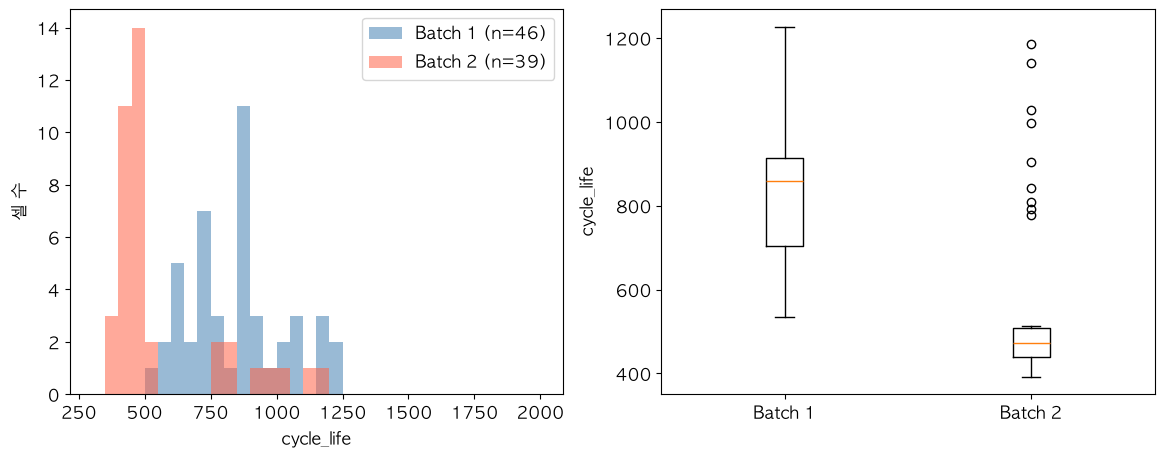

KS test Batch1 vs Batch2: stat=0.77, p=6.6e-13  (p가 작을수록 분포가 다름)
분류 기준 550 → 단수명 비율: Batch 1 2% / Batch 2 77%

[Batch 2 수명 상위 5 셀]


,cell,cycle_life,policy
78,34,1186.0,5.6C(26%)-4.5C-newstructure
77,33,1140.0,5.2C(58%)-4C-newstructure
81,43,1029.0,4.8C(80%)-4.8C-newstructure
83,45,997.0,5.6C(26%)-4.5C-newstructure
54,8,904.0,5.2C(58%)-4C-newstructure


[Batch 2 수명 하위 5 셀]


,cell,cycle_life,policy
65,19,392.0,6C(60%)-3C
52,6,393.0,3.6C(9%)-5C
61,15,396.0,3.6C(9%)-5C
67,21,408.0,6C(60%)-3C
74,30,412.0,5.6C(26%)-4.5C


In [15]:
T = 2
fig, ax = plt.subplots(1, 2, figsize=(14, 5)); bins = np.linspace(300, 2000, 35)
for n in (1, T):
    v = cb[cb.batch == n].cycle_life; ax[0].hist(v, bins=bins, alpha=.55, color=col[n], label=f'Batch {n} (n={len(v)})')
ax[0].set_xlabel('cycle_life'); ax[0].set_ylabel('셀 수'); ax[0].legend()
ax[1].boxplot([cb[cb.batch == n].cycle_life for n in (1, T)], tick_labels=['Batch 1', f'Batch {T}']); ax[1].set_ylabel('cycle_life')
plt.show()
s = ks_2samp(cb[cb.batch == 1].cycle_life, cb[cb.batch == T].cycle_life); print(f'KS test Batch1 vs Batch{T}: stat={s.statistic:.2f}, p={s.pvalue:.1e}  (p가 작을수록 분포가 다름)')
print(f'분류 기준 550 → 단수명 비율: Batch 1 {(cb[cb.batch==1].cycle_life<550).mean():.0%} / Batch {T} {(cb[cb.batch==T].cycle_life<550).mean():.0%}')
print(f'\n[Batch {T} 수명 상위 5 셀]'); display(cb[cb.batch == T].nlargest(5, 'cycle_life')[['cell', 'cycle_life', 'policy']])
print(f'[Batch {T} 수명 하위 5 셀]'); display(cb[cb.batch == T].nsmallest(5, 'cycle_life')[['cell', 'cycle_life', 'policy']])

In [16]:
# 가장 짧은 수명 셀 5개 vs 배치 중앙값 — 왜 짧은가? (IQR 이상치도 함께)
T = 2
f = early_feats(B[T][0], B[T][1]).join(cb[cb.batch == T].set_index('cell')[['policy', 'c_avg']])
cols = ['cycle_life', 'policy', 'c_avg', 'dQ_log_var', 'QD_mean', 'IR_mean', 'Tavg_mean']
med = f[cols].drop(columns='policy').median().rename('배치 중앙값')
display(pd.concat([f.nsmallest(5, 'cycle_life')[cols], med.to_frame().T]).round(3))
q1, q3 = f.cycle_life.quantile([.25, .75]); lo, hi = q1 - 1.5*(q3-q1), q3 + 1.5*(q3-q1)
print(f'IQR 이상치 기준: <{lo:.0f} 또는 >{hi:.0f}')
display(f[(f.cycle_life < lo) | (f.cycle_life > hi)][['cycle_life', 'policy']])
print('\nnewstructure 유무별 수명'); display(f.assign(newstructure=f.policy.str.contains('newstructure')).groupby('newstructure').cycle_life.agg(['count', 'mean', 'min', 'max']).round(0))


,cycle_life,policy,c_avg,dQ_log_var,QD_mean,IR_mean,Tavg_mean
19,392.0,6C(60%)-3C,4.800,-3.292,1.095,0.017,32.770
6,393.0,3.6C(9%)-5C,4.874,-3.530,1.093,0.016,33.817
15,396.0,3.6C(9%)-5C,4.874,-3.516,1.075,0.016,32.862
21,408.0,6C(60%)-3C,4.800,-3.327,1.101,0.017,33.598
30,412.0,5.6C(26%)-4.5C,4.786,-3.185,1.093,0.017,33.810
배치 중앙값,472.0,NaN,4.786,-3.487,1.097,0.016,33.016


IQR 이상치 기준: <336 또는 >612


,cycle_life,policy
cell,,
7,777.0,4.8C(80%)-4.8C-newstructure
8,904.0,5.2C(58%)-4C-newstructure
9,791.0,5.6C(26%)-4.5C-newstructure
32,809.0,4.8C(80%)-4.8C-newstructure
33,1140.0,5.2C(58%)-4C-newstructure
34,1186.0,5.6C(26%)-4.5C-newstructure
43,1029.0,4.8C(80%)-4.8C-newstructure
44,841.0,5.2C(58%)-4C-newstructure
45,997.0,5.6C(26%)-4.5C-newstructure



newstructure 유무별 수명


,count,mean,min,max
newstructure,,,,
False,30,453.0,392.0,514.0
True,9,942.0,777.0,1186.0


**관찰**
- Batch 2는 39셀(수명 없는 8셀은 VarCharge·SLOWCYCLE 특수 실험 셀이라 제외), 평균 566(392~1186), 중앙값 472, IQR 440~508. Batch 1(평균 845)보다 훨씬 짧음.
- 단수명(<500) 72%, 장수명(>1000) 8%. **두 덩어리로 갈라진 분포**: 좁은 단수명 덩어리(392~514, 30셀)와 777~1186에 흩어진 9셀. 그 사이(514~777)에는 셀이 없음.
- KS 검정 stat=0.77, p=6.6e-13 → **Batch 1과 분포가 다름**.
- 분류 기준 550 → 단수명 비율 Batch 1 2% vs Batch 2 77%로 정반대.
- 수명 상위 5셀은 모두 정책명에 `newstructure`가 붙은 셀. 하위 5셀은 6C(60%)-3C, 3.6C(9%)-5C 등.

**시사점**
- Batch 2의 77%(30/39)가 학습 수명 범위(534~1227) 아래(392~514) → **외삽 오차가 클 것으로 예상**, 원논문 대비 성능 저하의 주요 원인 후보.
- 분류(550)는 클래스 비율이 뒤집혀 평가가 불안정 → 회귀 선택을 뒷받침.
- 수명이 짧은 셀은 같은 절대 오차라도 MAPE가 크게 나옴 → 지표 해석 시 고려.

**짧은 셀 확인**
- IQR 이상치 9셀은 **전부 긴 쪽**(777~1186)이고 모두 `newstructure`. 짧은 쪽 이상치는 없음 → 392~514는 이상치가 아니라 **일반 셀의 분포**.
- 가장 짧은 셀(392~412)은 `6C(60%)-3C`, `3.6C(9%)-5C`, `5.6C(26%)-4.5C`. 평균 C-rate는 4.79~4.87로 Batch 2 중앙값(4.79)과 비슷함 → **충전 속도로는 설명되지 않음.**
- `dQ_log_var`는 5셀 중 3셀(−3.19~−3.33)이 중앙값(−3.49)보다 깊고(= 초기 열화가 빠름), 2셀(`3.6C(9%)-5C`, −3.52~−3.53)은 중앙값과 비슷함 → **ΔQ로도 일부만 설명됨.** 초기 용량·IR·온도는 중앙값과 차이 없음.
- `newstructure` 유무가 수명을 가름: 없음 30셀 평균 453(392~514) / 있음 9셀 평균 942(777~1186). (위 코드 셀 출력 참고)


## [B2] Q2. 열화 곡선

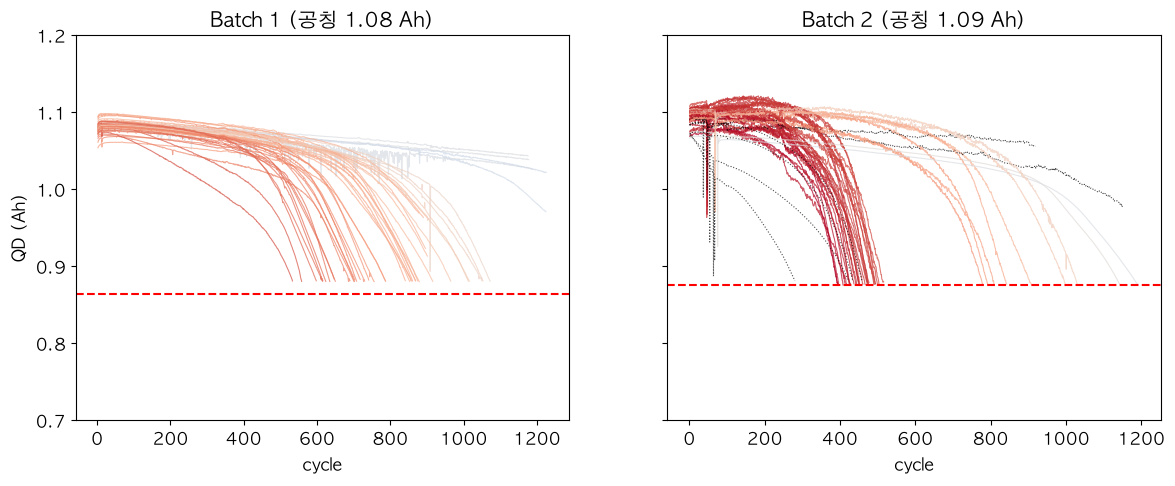

,초기기울기_중앙값_1e5,기울기_양수_비율,knee_중앙값,knee_수명비_중앙값
batch,,,,
1,-1.84,0.07,573.5,0.71
2,2.24,0.64,335.0,0.73


In [17]:
T = 2
fig, axs = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for a, n in zip(axs, (1, T)):
    d_ = B[n][0]; nom_ = d_[d_.cycle <= 5].groupby('cell').QDischarge.median().median()
    cl_ = d_[d_.QDischarge.between(nom_*0.8, nom_*1.2)]
    for c_, g_ in cl_.groupby('cell'):
        life_ = g_.cycle_life.iloc[0]
        nan_ = np.isnan(life_)   # 수명 없는 특수 실험 셀은 검정 점선으로 구분
        a.plot(g_.cycle, g_.QDischarge, lw=.8, alpha=.7, color='black' if nan_ else cmap((life_-lo_)/(hi_-lo_)), ls=':' if nan_ else '-')
    a.axhline(nom_*0.8, color='red', ls='--'); a.set_title(f'Batch {n} (공칭 {nom_:.2f} Ah)'); a.set_xlabel('cycle'); a.set_ylim(0.7, 1.2)
axs[0].set_ylabel('QD (Ah)'); plt.show()
display(sk[sk.batch.isin([1, T])].groupby('batch').agg(초기기울기_중앙값_1e5=('slope', lambda s: s.median() * 1e5), 기울기_양수_비율=('slope', lambda s: (s > 0).mean()),
    knee_중앙값=('knee', 'median'), knee_수명비_중앙값=('knee_ratio', 'median')).round(2))   # 초기 기울기 = 사이클 20~100의 QD 기울기 (단위 1e-5 Ah/cycle)


**관찰**
- Batch 2는 초기에 용량이 **약간 오르는** 셀이 많음(사이클 20~100 기울기가 양(+)인 셀 64% vs Batch 1 7%). 상승 폭은 작지만 방향이 Batch 1과 다름.
- 단수명 셀 대부분이 약 350~500 사이클에서 한꺼번에 급락(절벽형). 장수명(800~1,030) 셀은 600~700 사이클까지 평평하다가 급락 → Batch 1과 비슷한 모양.
- knee 중앙값 335 vs Batch 1 574 (수명이 짧아서 앞당겨짐). 수명 대비 비율은 0.73 vs 0.71로 비슷함 → '수명의 약 70%쯤에서 꺾인다'는 패턴이 두 배치에서 비슷.

**시사점**
- 초기 용량 거동이 Batch 1과 다르므로 **초기 QD 평균/기울기 feature는 배치 간 신뢰하기 어렵다** (Q5에서도 수명과의 상관 부호가 바뀜: QD_slope +0.20 → −0.44).
- 곡선 모양은 Batch 1의 짧은 셀과 비슷하고 급락 시점만 더 빠름 → 모양 자체보다 **급락 시점을 초기 신호(ΔQ)로 예측**할 수 있는지가 관건.


## [B2] Q3. ΔQ(V) 곡선

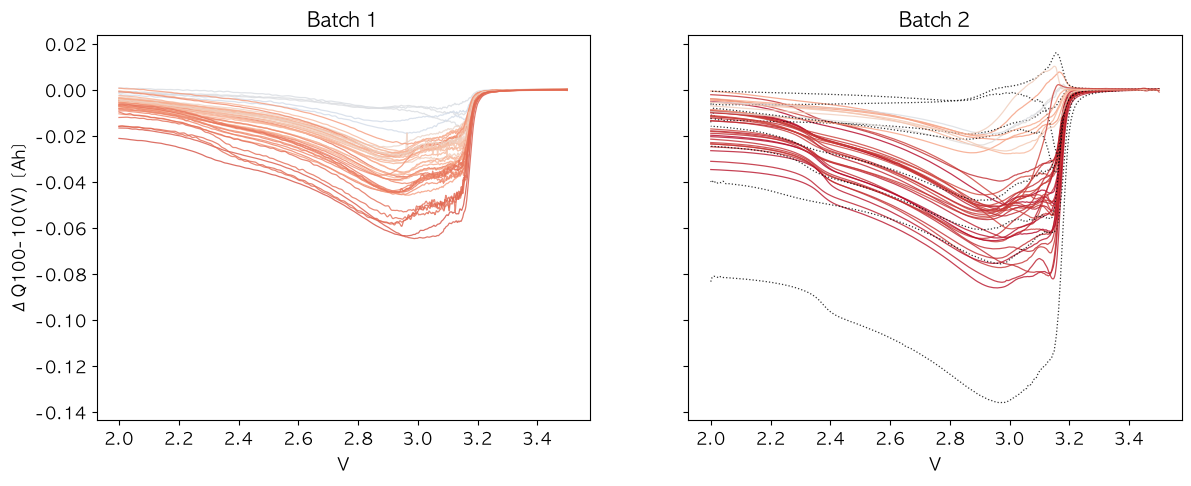

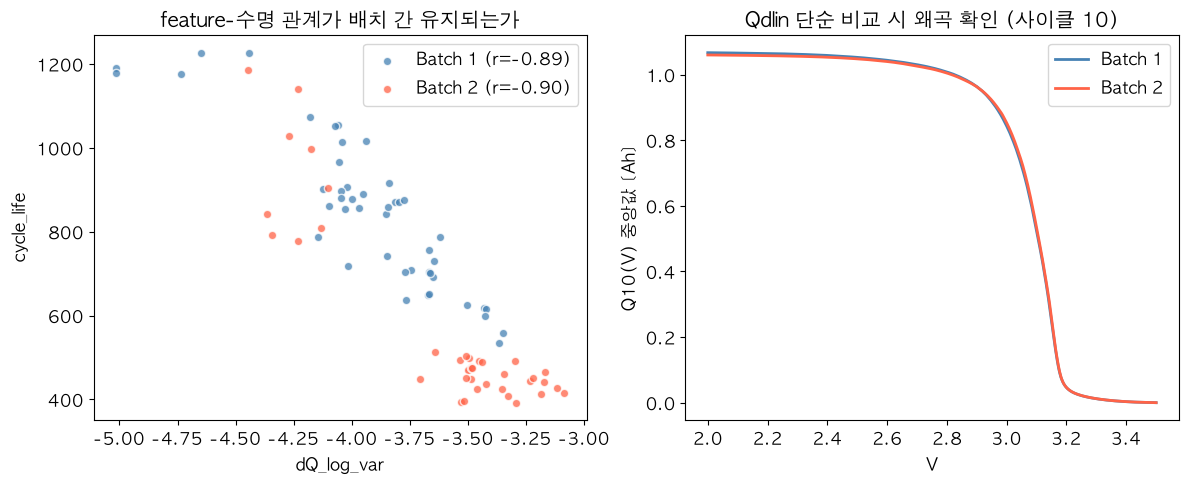

Batch 1: ΔQ 최솟값 범위 -0.065~-0.008, 중앙값 -0.036 | ΔQ 양(+) 최댓값 0.001
Batch 2: ΔQ 최솟값 범위 -0.086~-0.019, 중앙값 -0.054 | ΔQ 양(+) 최댓값 0.010


In [18]:
T = 2
fig, axs = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for a, n in zip(axs, (1, T)):
    c_ = B[n][1]; dq_ = B[n][3]
    for i in range(len(dq_)):
        l_ = c_.cycle_life[i]; nan_ = np.isnan(l_)   # 수명 없는 특수 실험 셀은 검정 점선으로 구분
        a.plot(V, dq_[i], lw=.9, alpha=.8, color='black' if nan_ else cmap((l_-lo_)/(hi_-lo_)), ls=':' if nan_ else '-')
    a.set_title(f'Batch {n}'); a.set_xlabel('V')
axs[0].set_ylabel('ΔQ100-10(V) [Ah]'); plt.show()

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
for n in (1, T):
    s = cb[cb.batch == n]; r_ = s.dQ_log_var.corr(s.cycle_life)
    ax[0].scatter(s.dQ_log_var, s.cycle_life, c=col[n], alpha=.75, edgecolors='white', label=f'Batch {n} (r={r_:.2f})')
    ax[1].plot(V, np.nanmedian(B[n][2]['q10'], axis=0), color=col[n], lw=2, label=f'Batch {n}')
ax[0].set_xlabel('dQ_log_var'); ax[0].set_ylabel('cycle_life'); ax[0].legend(); ax[0].set_title('feature-수명 관계가 배치 간 유지되는가')
ax[1].set_xlabel('V'); ax[1].set_ylabel('Q10(V) 중앙값 [Ah]'); ax[1].legend(); ax[1].set_title('Qdlin 단순 비교 시 왜곡 확인 (사이클 10)')
plt.show()
for n in (1, T):   # 수명 있는 셀의 ΔQ 최솟값(가장 깊은 값)과 양(+) 최댓값
    ok = ~np.isnan(B[n][1].cycle_life.values); m_ = np.nanmin(B[n][3][ok], axis=1)
    print(f'Batch {n}: ΔQ 최솟값 범위 {m_.min():.3f}~{m_.max():.3f}, 중앙값 {np.median(m_):.3f} | ΔQ 양(+) 최댓값 {np.nanmax(B[n][3][ok]):.3f}')


**관찰**
- 곡선은 Batch 1처럼 3.2V에서 수렴하지만, 단수명(진한 빨강) 셀 다수에서 3.0~3.15V 구간이 위로 볼록해짐(양(+)값 최대 0.010Ah, Batch 1은 0.001). 수명 없는 셀 하나(cell 36, VarCharge-8C 특수 실험)는 −0.136Ah까지 내려가는 이상 곡선이며 분석에서 제외됨.
- Batch 2의 ΔQ는 Batch 1보다 **전반적으로 깊음**: 최솟값 중앙값 −0.054 vs −0.036, 범위 −0.086~−0.019 vs −0.065~−0.008 (단수명 셀이 많기 때문).
- `dQ_log_var`와 수명의 상관은 Batch 2에서 r=−0.90 (Batch 1 −0.89)로 **거의 동일**.
- Batch 2의 단수명 덩어리(dQ_log_var 약 −3.6~−3.1, 수명 390~510)는 Batch 1 추세선을 연장한 방향에 있음. 장수명(1000+) 셀도 같은 선 근처이나, 수명 780~850 셀 일부는 선보다 왼쪽(같은 수명에서 dQ_log_var가 더 낮음)에 있어 **모든 셀이 같은 선 위는 아님**.
- 사이클 10의 Q(V) 곡선은 두 배치가 거의 겹침.

**시사점**
- **`dQ_log_var`는 배치가 바뀌어도 수명과의 상관 방향·크기가 유지**(r −0.89 → −0.90) → 일반화에 유리한 핵심 feature. 단 Batch 1 학습 모델이 Batch 2 수명을 정확히 맞출지는 별도로 평가해야 함(Day 2 최종 평가).
- Batch 2의 `dQ_log_var`(−4.45~−3.09) 중 11/39셀(28%)이 Batch 1 범위(−5.01~−3.35)의 오른쪽 밖에 있음 → 외삽이 가능한 선형 계열 모델이 유리.
- 사이클 10 곡선이 겹치므로 배치별 Qdlin 보정은 Batch 2에서는 크게 필요 없어 보임.


## [B2] Q4. 충전 조건(C-rate)

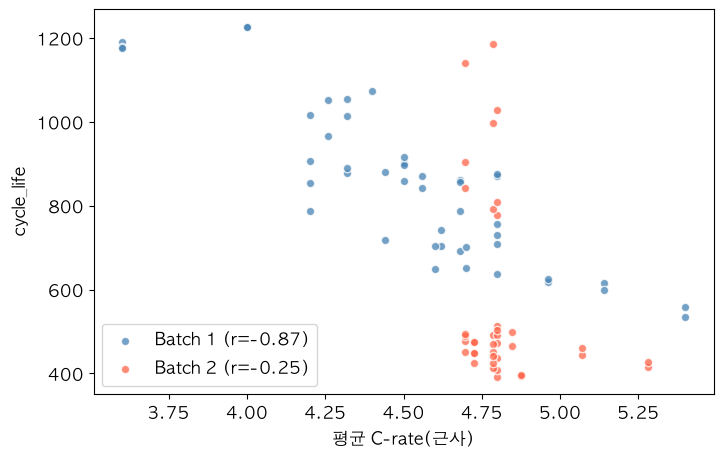

,정책수,c_avg_평균,c_avg_최소,c_avg_최대
batch,,,,
1,23,4.53,3.6,5.40
2,12,4.81,4.7,5.28


Batch 1·2 공통 정책 수: 2
Batch 2 정책별 평균 수명:


,mean,count
policy,,
5.6C(26%)-4.5C-newstructure,991.0,3
5.2C(58%)-4C-newstructure,962.0,3
4.8C(80%)-4.8C-newstructure,872.0,3
4.8C(80%)-4.8C,484.0,5
4.65C(44%)-5C,482.0,2
5.2C(58%)-4C,478.0,4
5.2C(50%)-4.25C,454.0,5
4.65C(69%)-6C,452.0,2
5.6C(26%)-4.5C,448.0,6



Batch 2 newstructure 제외 30셀: r=-0.31 (전체 -0.25) | c_avg 4.8 근처(10셀) 수명 범위 392~1029
공통 정책 평균 수명 (Batch 1 → Batch 2):


,Batch 1,Batch 2
policy,,
4.8C(80%)-4.8C,753.0,484.0
6C(60%)-3C,744.0,400.0


In [19]:
T = 2
fig, ax = plt.subplots(figsize=(8, 5))
for n in (1, T):
    s = cb[cb.batch == n].dropna(subset=['c_avg']); ax.scatter(s.c_avg, s.cycle_life, c=col[n], alpha=.75, edgecolors='white', label=f'Batch {n} (r={s.c_avg.corr(s.cycle_life):.2f})')
ax.set_xlabel('평균 C-rate(근사)'); ax.set_ylabel('cycle_life'); ax.legend(); plt.show()
display(cb[cb.batch.isin([1, T])].groupby('batch').agg(정책수=('policy', 'nunique'), c_avg_평균=('c_avg', 'mean'), c_avg_최소=('c_avg', 'min'), c_avg_최대=('c_avg', 'max')).round(2))
print(f'Batch 1·{T} 공통 정책 수:', len(set(cb[cb.batch == 1].policy) & set(cb[cb.batch == T].policy)))
print(f'Batch {T} 정책별 평균 수명:'); display(cb[cb.batch == T].groupby('policy').cycle_life.agg(['mean', 'count']).sort_values('mean', ascending=False).round(0))
s2 = cb[cb.batch == T].dropna(subset=['c_avg']); new_ = s2.policy.str.contains('newstructure'); o_ = s2[~new_]
print(f'\nBatch {T} newstructure 제외 {len(o_)}셀: r={o_.c_avg.corr(o_.cycle_life):.2f} (전체 {s2.c_avg.corr(s2.cycle_life):.2f}) | c_avg 4.8 근처({s2.c_avg.round(2).eq(4.8).sum()}셀) 수명 범위 {s2[s2.c_avg.round(2) == 4.8].cycle_life.min():.0f}~{s2[s2.c_avg.round(2) == 4.8].cycle_life.max():.0f}')
common = sorted(set(cb[cb.batch == 1].policy) & set(cb[cb.batch == T].policy))
print('공통 정책 평균 수명 (Batch 1 → Batch %d):' % T); display(pd.DataFrame({f'Batch {n}': cb[(cb.batch == n) & cb.policy.isin(common)].groupby('policy').cycle_life.mean() for n in (1, T)}).round(0))


**관찰**
- Batch 2의 평균 C-rate(근사)는 4.7~5.3의 좁은 범위(Batch 1은 3.6~5.4)에 몰려 있고, 수명과의 상관은 r=−0.25 (Batch 1은 −0.87).
- **같은 정책인데 수명이 약 2배 차이**: 4.8C(80%)-4.8C = 484(5셀) vs -newstructure 872(3셀), 5.2C(58%)-4C = 478 vs 962, 5.6C(26%)-4.5C = 448(6셀) vs 991(3셀).
- 같은 평균 C-rate(4.8 근처)에서 수명이 392~1,029로 퍼짐 → 충전 조건이 아니라 `newstructure` 표기 그룹이 수명을 가르는 것으로 보임(셀 구조·제조 조건 변경이라는 **가설**, 확인 필요).
- 단 `newstructure` 9셀을 빼도 상관이 r=−0.31로 약함 → 상관이 낮은 이유는 `newstructure`만이 아니라 **C-rate 범위가 좁기(4.7~5.3) 때문**이기도 함.
- Batch 1·2 공통 정책은 2개뿐이고(`4.8C(80%)-4.8C`, `6C(60%)-3C`), 둘 다 Batch 2에서 수명이 짧음(753 → 484, 744 → 400) → **같은 충전 정책이라도 배치가 다르면 수명이 달라짐.**

**시사점**
- **충전 정책 feature는 배치 간 일반화가 안 된다** (r −0.87 → −0.25). 핵심 feature에서 제외하거나 보조로만 사용.
- ΔQ 기반 feature는 `newstructure` 셀도 대체로 같은 방향의 관계(Batch 2 r=−0.90)를 따르므로(Q3) 셀 상태를 직접 반영함 → 정책보다 셀 신호 중심으로 설계.


## [B2] Q5. 상관관계

In [20]:
T = 2
display(corr_b[['Batch 1', f'Batch {T}']].assign(차이=lambda x: x[f'Batch {T}'] - x['Batch 1']).round(2).style.background_gradient(cmap='RdBu_r', vmin=-1, vmax=1, subset=['Batch 1', f'Batch {T}']))

,Batch 1,Batch 2,차이
QD_mean,0.190000,-0.330000,-0.530000
IR_mean,0.180000,-0.350000,-0.530000
Tavg_mean,-0.480000,0.420000,0.910000
chargetime_mean,0.580000,0.090000,-0.490000
QD_slope,0.200000,-0.440000,-0.640000
dQ_log_var,-0.890000,-0.900000,-0.020000
dQ_log_min,-0.870000,-0.890000,-0.010000


**관찰**
- `dQ_log_var` −0.90, `dQ_log_min` −0.89로 Batch 1(−0.89, −0.87)과 사실상 동일. (평균 C-rate는 Q4에서 −0.87 → −0.25로 약해짐.)
- 그 외 feature는 크게 흔들림: **부호가 반전**된 것은 Tavg_mean −0.48 → +0.42, QD_slope +0.20 → −0.44, QD_mean +0.19 → −0.33, IR_mean +0.18 → −0.35. chargetime_mean은 부호는 같지만 **+0.58 → +0.09로 거의 사라짐**(Tmax_mean도 −0.40 → +0.02).
- 단 표본이 작아 해석에 주의: 유의 수준(p<0.05)에 필요한 |r|이 Batch 1(46셀) 약 0.29, Batch 2(39셀) 약 0.32. Batch 1에서 QD_mean·IR_mean·QD_slope(+0.18~+0.20)는 원래 유의하지 않았으므로, 이 feature들의 '반전'은 **원래 약한 신호가 노이즈로 흔들린 것**에 가까움.

**시사점**
- **ΔQ 계열만 배치 간에 안정적**(−0.89/−0.87 → −0.90/−0.89). 온도·충전시간·초기 용량 계열은 Batch 1에서 약하거나(초기 용량·IR) 배치마다 크기·방향이 달라져(온도·충전시간) 일반화 위험이 큼 → 제외 또는 최소한으로.
- 주의: feature 선택 근거는 Batch 1(상관 높음)이며, Batch 2는 '안정한지' 점검하는 용도로만 사용.


---
# 🟩 Batch 3 vs Batch 1

> **Batch 3 = 선택 과제(추가 평가), 이번에는 EDA만.** 과제 설명상 확인할 포인트: ① 수명 분포가 다름 ② 충전 곡선 시작점이 달라 `Qdlin` 단순 비교 시 왜곡 ③ 일부 셀 데이터 품질 문제(수명 NaN 셀 제외)

In [21]:
T = 3                                                   # 비교 대상 배치
S = cb[cb.batch.isin([1, T])]
print(f'[핵심 숫자] Batch 1 vs Batch {T}')
display(S.groupby('batch').agg(셀수=('cell', 'count'), 평균수명=('cycle_life', 'mean'), 최소=('cycle_life', 'min'), 최대=('cycle_life', 'max'),
    장수명비율_1000초과=('cycle_life', lambda s: (s > 1000).mean()), 단수명비율_500미만=('cycle_life', lambda s: (s < 500).mean()),
    dQ와_수명_상관=('cell', lambda x: S.loc[x.index].dQ_log_var.corr(S.loc[x.index].cycle_life)),
    평균Crate와_수명_상관=('cell', lambda x: S.loc[x.index].c_avg.corr(S.loc[x.index].cycle_life))).round(2))

[핵심 숫자] Batch 1 vs Batch 3


,셀수,평균수명,최소,최대,장수명비율_1000초과,단수명비율_500미만,dQ와_수명_상관,평균Crate와_수명_상관
batch,,,,,,,,
1,46,844.72,534.0,1227.0,0.22,0.0,-0.89,-0.87
3,44,1059.66,541.0,1935.0,0.52,0.0,-0.70,-0.29


## [B3] Q1. Cycle Life 분포

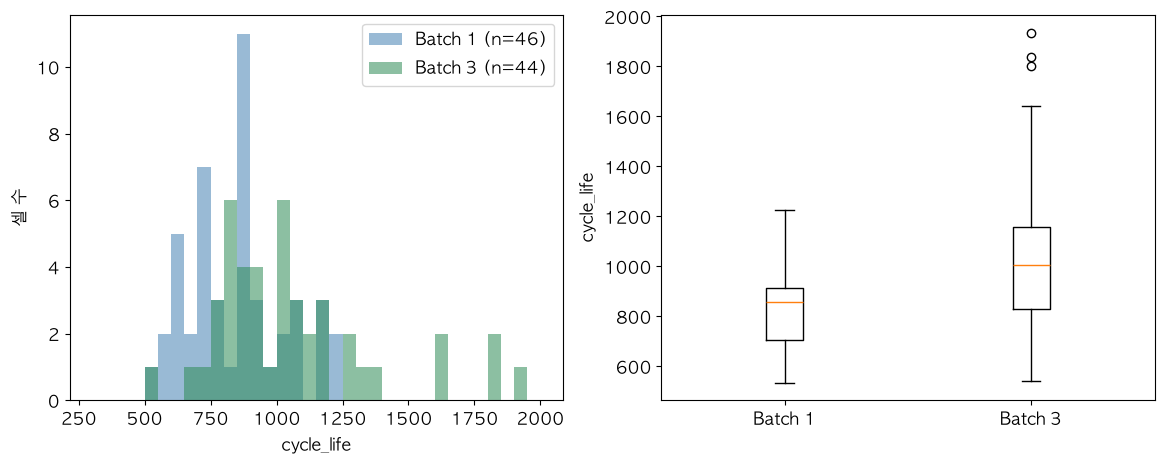

KS test Batch1 vs Batch3: stat=0.40, p=1.1e-03  (p가 작을수록 분포가 다름)
분류 기준 550 → 단수명 비율: Batch 1 2% / Batch 3 2%

[Batch 3 수명 상위 5 셀]


,cell,cycle_life,policy
121,38,1935.0,5C(67%)-4C-newstructure
92,7,1836.0,4.8C(80%)-4.8C-newstructure
128,45,1801.0,4.8C(80%)-4.8C-newstructure
125,42,1642.0,4.8C(80%)-4.8C-newstructure
101,16,1638.0,4.8C(80%)-4.8C-newstructure


[Batch 3 수명 하위 5 셀]


,cell,cycle_life,policy
112,28,541.0,3.7C(31%)-5.9C-newstructure
91,6,667.0,3.7C(31%)-5.9C-newstructure
115,31,731.0,5.9C(60%)-3.1C-newstructure
106,21,772.0,3.7C(31%)-5.9C-newstructure
124,41,786.0,5.6C(36%)-4.3C-newstructure


In [22]:
T = 3
fig, ax = plt.subplots(1, 2, figsize=(14, 5)); bins = np.linspace(300, 2000, 35)
for n in (1, T):
    v = cb[cb.batch == n].cycle_life; ax[0].hist(v, bins=bins, alpha=.55, color=col[n], label=f'Batch {n} (n={len(v)})')
ax[0].set_xlabel('cycle_life'); ax[0].set_ylabel('셀 수'); ax[0].legend()
ax[1].boxplot([cb[cb.batch == n].cycle_life for n in (1, T)], tick_labels=['Batch 1', f'Batch {T}']); ax[1].set_ylabel('cycle_life')
plt.show()
s = ks_2samp(cb[cb.batch == 1].cycle_life, cb[cb.batch == T].cycle_life); print(f'KS test Batch1 vs Batch{T}: stat={s.statistic:.2f}, p={s.pvalue:.1e}  (p가 작을수록 분포가 다름)')
print(f'분류 기준 550 → 단수명 비율: Batch 1 {(cb[cb.batch==1].cycle_life<550).mean():.0%} / Batch {T} {(cb[cb.batch==T].cycle_life<550).mean():.0%}')
print(f'\n[Batch {T} 수명 상위 5 셀]'); display(cb[cb.batch == T].nlargest(5, 'cycle_life')[['cell', 'cycle_life', 'policy']])
print(f'[Batch {T} 수명 하위 5 셀]'); display(cb[cb.batch == T].nsmallest(5, 'cycle_life')[['cell', 'cycle_life', 'policy']])

In [23]:
# 가장 짧은 수명 셀 5개 vs 배치 중앙값 — 왜 짧은가? (IQR 이상치도 함께)
T = 3
f = early_feats(B[T][0], B[T][1]).join(cb[cb.batch == T].set_index('cell')[['policy', 'c_avg']])
cols = ['cycle_life', 'policy', 'c_avg', 'dQ_log_var', 'QD_mean', 'IR_mean', 'Tavg_mean']
med = f[cols].drop(columns='policy').median().rename('배치 중앙값')
display(pd.concat([f.nsmallest(5, 'cycle_life')[cols], med.to_frame().T]).round(3))
q1, q3 = f.cycle_life.quantile([.25, .75]); lo, hi = q1 - 1.5*(q3-q1), q3 + 1.5*(q3-q1)
print(f'IQR 이상치 기준: <{lo:.0f} 또는 >{hi:.0f}')
display(f[(f.cycle_life < lo) | (f.cycle_life > hi)][['cycle_life', 'policy']])
print(f'\nBatch {T} 정책별 수명 (평균 C-rate 높은 순)'); display(cb[cb.batch == T].groupby('policy').agg(c_avg=('c_avg', 'first'), 셀수=('cell', 'count'), 평균수명=('cycle_life', 'mean'), 최소=('cycle_life', 'min'), 최대=('cycle_life', 'max')).sort_values('c_avg', ascending=False).round(2))
nan_ = B[T][1][B[T][1].cycle_life.isna()]; nom_ = B[T][0][B[T][0].cycle <= 5].QDischarge.median()
print('수명 NaN 셀: 마지막 20사이클 QD 중앙값 vs EOL(공칭×0.8 = %.3f)' % (nom_ * .8)); display(B[T][0][B[T][0].cell.isin(nan_.cell) & (B[T][0].cycle_life.isna())].groupby('cell').apply(lambda g: pd.Series({'마지막_사이클': g.cycle.max(), '마지막20_QD중앙값': g.QDischarge.iloc[-20:].median()})).round(3))


,cycle_life,policy,c_avg,dQ_log_var,QD_mean,IR_mean,Tavg_mean
28,541.0,3.7C(31%)-5.9C-newstructure,5.218,-3.452,1.045,0.013,35.695
6,667.0,3.7C(31%)-5.9C-newstructure,5.218,-3.526,1.054,0.014,34.107
31,731.0,5.9C(60%)-3.1C-newstructure,4.780,-3.840,1.071,0.016,33.999
21,772.0,3.7C(31%)-5.9C-newstructure,5.218,-3.704,1.062,0.014,34.898
41,786.0,5.6C(36%)-4.3C-newstructure,4.768,-4.220,1.054,0.018,33.639
배치 중앙값,1005.5,NaN,4.768,-4.175,1.068,0.015,34.111


IQR 이상치 기준: <337 또는 >1646


,cycle_life,policy
cell,,
7,1836.0,4.8C(80%)-4.8C-newstructure
38,1935.0,5C(67%)-4C-newstructure
45,1801.0,4.8C(80%)-4.8C-newstructure



Batch 3 정책별 수명 (평균 C-rate 높은 순)


,c_avg,셀수,평균수명,최소,최대
policy,,,,,
3.7C(31%)-5.9C-newstructure,5.22,3,660.00,541.0,772.0
4.8C(80%)-4.8C-newstructure,4.80,6,1564.17,1078.0,1836.0
5.9C(15%)-4.6C-newstructure,4.80,2,867.00,858.0,876.0
5.6C(19%)-4.6C-newstructure,4.79,8,1001.38,796.0,1267.0
5.9C(60%)-3.1C-newstructure,4.78,2,866.50,731.0,1002.0
5.6C(36%)-4.3C-newstructure,4.77,8,930.88,786.0,1155.0
5.3C(54%)-4C-newstructure,4.70,8,1074.38,935.0,1315.0
5C(67%)-4C-newstructure,4.67,7,1105.71,813.0,1935.0


수명 NaN 셀: 마지막 20사이클 QD 중앙값 vs EOL(공칭×0.8 = 0.853)


,마지막_사이클,마지막20_QD중앙값
cell,,
23,2189.0,0.940
32,2237.0,0.975


**관찰**
- Batch 3는 44셀(수명 없는 2셀 제외), 평균 1060(541~1935). 장수명(>1000) 52%, 단수명(<500) 0%. 박스플롯 중앙값 약 1005.
- KS 검정 stat=0.40, p=1.1e-3 → Batch 1과 분포가 다름(Batch 2의 stat 0.77만큼은 아니지만 유의).
- 수명 상위 5셀(1638~1935)은 4.8C(80%)-4.8C-newstructure 4개(이 정책 6셀 평균 1564)와 5C(67%)-4C-newstructure 1개. 최댓값 1935는 Batch 1 최댓값(1227)을 크게 넘음. IQR 이상치는 1801·1836·1935 3셀(모두 긴 쪽).
- 수명이 NaN인 2셀(cell 23, 32)은 2189, 2237 사이클까지 기록됐고 마지막 QD가 0.94, 0.975로 EOL(0.853)에 한참 못 미침 → 수명이 2,200 이상인데 측정이 끝나지 않은 셀. 제외하면서 **가장 긴 수명 셀이 빠짐**(실제 수명 분포는 더 오른쪽까지 이어짐).

**시사점**
- Batch 1 학습 범위(≤1227) 밖에 장수명 셀이 많음 → **트리 계열 모델은 학습 범위 밖 값을 예측하지 못해 과소예측**할 가능성. 외삽이 되는 선형 계열이 유리. (Batch 3는 이번에 EDA만 하므로 모델 평가는 하지 않음)
- 분류(550) 기준은 Batch 3에서는 클래스가 거의 한쪽(단수명 2%)이라 의미가 없음. Batch 1도 2%라서 550 기준으로는 Batch 1과 3이 비슷하고 Batch 2(77%)만 다름 → 분류 기준의 불안정성은 배치마다 방향이 다름.

**짧은 셀 확인**
- IQR 이상치는 **긴 쪽 3셀**(1801~1935)뿐. 짧은 쪽 이상치는 없음.
- 가장 짧은 셀 541은 `3.7C(31%)-5.9C-newstructure`. 이 정책은 **3셀 전부**(541·667·772)가 하위 5셀에 들어가고 평균 660 → 정책이 원인으로 보임. 평균 C-rate 5.22로 Batch 3에서 가장 빠른 정책(나머지 7정책은 4.67~4.80).
- 541 셀은 하위 5셀 중 초기 용량(1.045)·IR(0.013)이 가장 낮고 평균 온도(35.7℃)가 가장 높음. `dQ_log_var` −3.45로 배치 중앙값(−4.18)보다 훨씬 높음(= ΔQ가 깊음, 초기 열화가 빠름). 급속충전, 고온, 빠른 초기 열화가 한 셀에 겹쳐 있음.
- 같은 정책 안에서도 541~772로 퍼짐 → 셀 편차가 있음.


## [B3] Q2. 열화 곡선

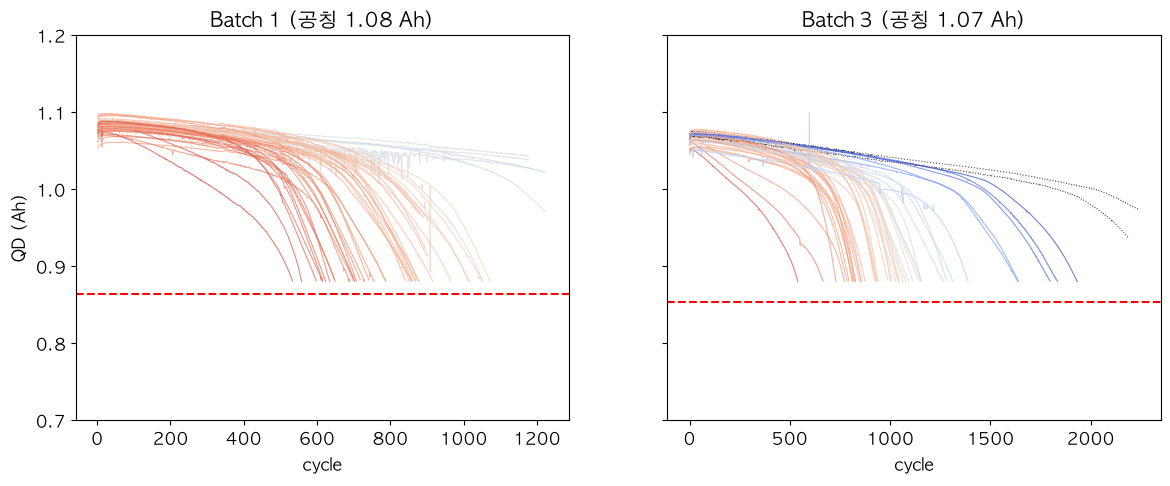

,초기기울기_중앙값_1e5,기울기_양수_비율,knee_중앙값,knee_수명비_중앙값
batch,,,,
1,-1.84,0.07,573.5,0.71
3,-2.16,0.00,764.5,0.76


In [24]:
T = 3
fig, axs = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for a, n in zip(axs, (1, T)):
    d_ = B[n][0]; nom_ = d_[d_.cycle <= 5].groupby('cell').QDischarge.median().median()
    cl_ = d_[d_.QDischarge.between(nom_*0.8, nom_*1.2)]
    for c_, g_ in cl_.groupby('cell'):
        life_ = g_.cycle_life.iloc[0]
        nan_ = np.isnan(life_)   # 수명 없는 셀은 검정 점선으로 구분
        a.plot(g_.cycle, g_.QDischarge, lw=.8, alpha=.7, color='black' if nan_ else cmap((life_-lo_)/(hi_-lo_)), ls=':' if nan_ else '-')
    a.axhline(nom_*0.8, color='red', ls='--'); a.set_title(f'Batch {n} (공칭 {nom_:.2f} Ah)'); a.set_xlabel('cycle'); a.set_ylim(0.7, 1.2)
axs[0].set_ylabel('QD (Ah)'); plt.show()
display(sk[sk.batch.isin([1, T])].groupby('batch').agg(초기기울기_중앙값_1e5=('slope', lambda s: s.median() * 1e5), 기울기_양수_비율=('slope', lambda s: (s > 0).mean()),
    knee_중앙값=('knee', 'median'), knee_수명비_중앙값=('knee_ratio', 'median')).round(2))   # 초기 기울기 = 사이클 20~100의 QD 기울기 (단위 1e-5 Ah/cycle)


**관찰**
- 공칭 용량 1.07Ah(Batch 1 1.08Ah). 열화 곡선 모양은 Batch 1과 비슷함(완만하게 줄다 후반에 가속). 분석 셀의 수명 축이 1,935 사이클까지 길어지고, 수명 없는 2셀(검정 점선)은 약 2,200 사이클까지 이어지며 마지막 QD가 0.94~0.975로 EOL 아래로 내려가지 않음.
- Batch 2와 달리 **초기 용량 상승이 없음**: 사이클 20~100 기울기가 모두 음(−)(양수 비율 0%, 중앙값 −2.2e-5 Ah/cycle로 Batch 1의 −1.8e-5와 비슷). 일부 셀에 스파이크(예: 600 사이클 부근 1.10Ah)가 있음.
- knee 중앙값 765 vs Batch 1 574 (수명이 길어서 늦춰짐). 수명 대비 비율은 0.76 vs 0.71로 비슷(Batch 2는 0.73).

**시사점**
- 열화 양상이 Batch 1과 유사하고 초기 용량 거동도 같은 방향 → 달라진 것은 수명 스케일. 단 이것만으로 feature를 재사용할 수 있다고 단정할 수는 없고, ΔQ 상관(Q3, Q5)으로 확인해야 함.
- 수명 대비 knee 비율이 세 배치(0.71/0.73/0.76)에서 비슷하므로 열화 모양은 유사하다고 판단.


## [B3] Q3. ΔQ(V) 곡선

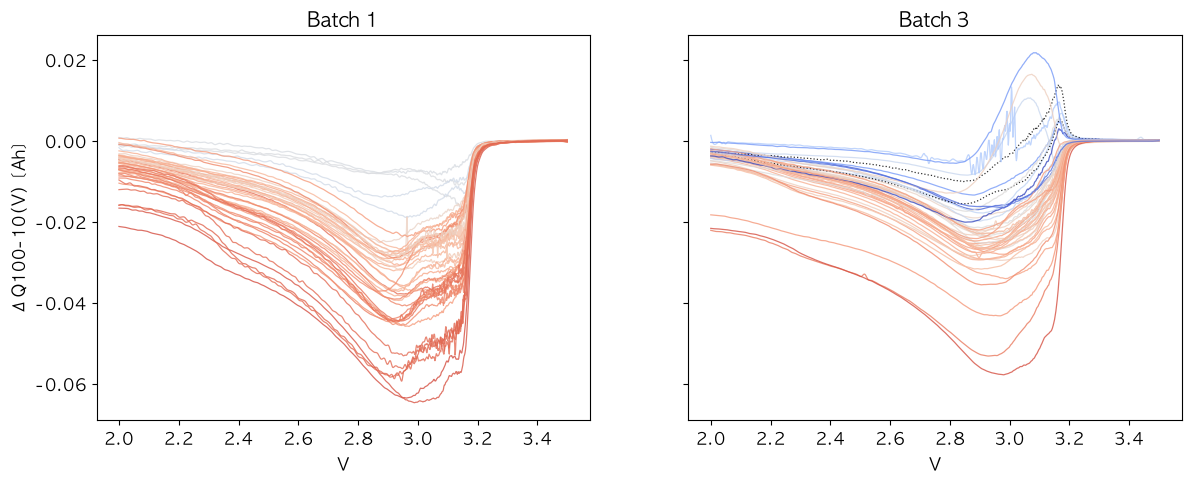

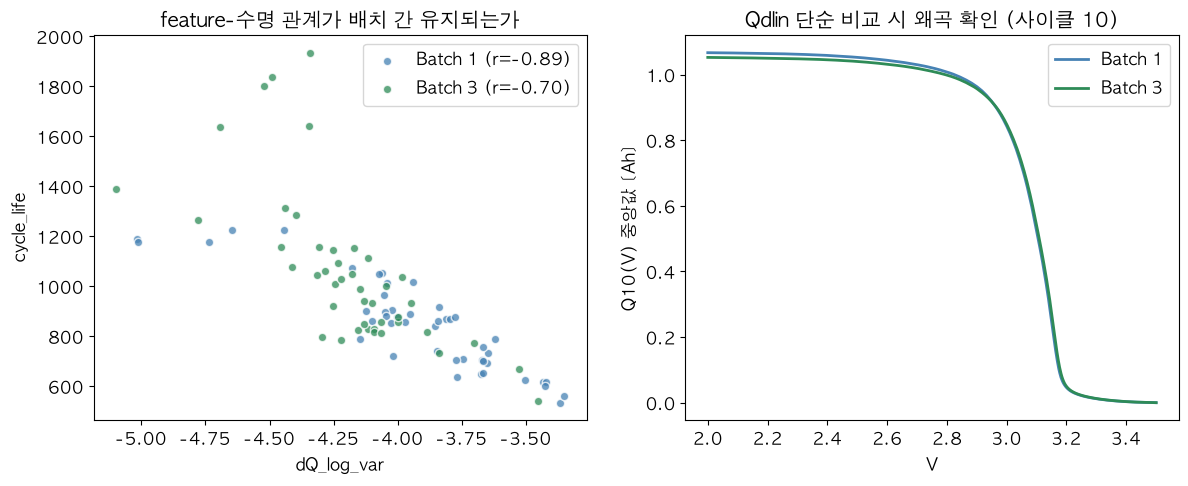

Batch 1: ΔQ 최솟값 -0.065~-0.008 (중앙값 -0.036) | 양(+) 최댓값 0.001, 양(+)볼록 셀(>0.002) 0개
   r=-0.89, Spearman=-0.87 | 양(+)볼록 셀 제외 r=-0.89 | 수명>=1500 제외 r=-0.89 (제외 0셀)
Batch 3: ΔQ 최솟값 -0.058~-0.006 (중앙값 -0.025) | 양(+) 최댓값 0.022, 양(+)볼록 셀(>0.002) 8개
   r=-0.70, Spearman=-0.80 | 양(+)볼록 셀 제외 r=-0.73 | 수명>=1500 제외 r=-0.82 (제외 5셀)
Batch 3 양(+)볼록 셀:


,cell,cycle_life,policy,dQ_log_var,ΔQ_최댓값
41,43,1046.0,5C(67%)-4C-newstructure,-4.317,0.016
37,39,1156.0,5.3C(54%)-4C-newstructure,-4.455,0.006
2,2,1267.0,5.6C(19%)-4.6C-newstructure,-4.779,0.011
17,17,1315.0,5.3C(54%)-4C-newstructure,-4.440,0.007
35,37,1390.0,4.8C(80%)-4.8C-newstructure,-5.099,0.013
16,16,1638.0,4.8C(80%)-4.8C-newstructure,-4.695,0.005
40,42,1642.0,4.8C(80%)-4.8C-newstructure,-4.346,0.022
36,38,1935.0,5C(67%)-4C-newstructure,-4.342,0.003


In [25]:
T = 3
fig, axs = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for a, n in zip(axs, (1, T)):
    c_ = B[n][1]; dq_ = B[n][3]
    for i in range(len(dq_)):
        l_ = c_.cycle_life[i]; nan_ = np.isnan(l_)   # 수명 없는 셀은 검정 점선으로 구분
        a.plot(V, dq_[i], lw=.9, alpha=.8, color='black' if nan_ else cmap((l_-lo_)/(hi_-lo_)), ls=':' if nan_ else '-')
    a.set_title(f'Batch {n}'); a.set_xlabel('V')
axs[0].set_ylabel('ΔQ100-10(V) [Ah]'); plt.show()

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
for n in (1, T):
    s = cb[cb.batch == n]; r_ = s.dQ_log_var.corr(s.cycle_life)
    ax[0].scatter(s.dQ_log_var, s.cycle_life, c=col[n], alpha=.75, edgecolors='white', label=f'Batch {n} (r={r_:.2f})')
    ax[1].plot(V, np.nanmedian(B[n][2]['q10'], axis=0), color=col[n], lw=2, label=f'Batch {n}')
ax[0].set_xlabel('dQ_log_var'); ax[0].set_ylabel('cycle_life'); ax[0].legend(); ax[0].set_title('feature-수명 관계가 배치 간 유지되는가')
ax[1].set_xlabel('V'); ax[1].set_ylabel('Q10(V) 중앙값 [Ah]'); ax[1].legend(); ax[1].set_title('Qdlin 단순 비교 시 왜곡 확인 (사이클 10)')
plt.show()
from scipy.stats import spearmanr
for n in (1, T):   # 수명 있는 셀의 ΔQ 요약과 상관 (양(+) 볼록 셀 / 초장수명 셀을 빼면 어떻게 되는가)
    ok = ~np.isnan(B[n][1].cycle_life.values); dq_ = B[n][3][ok]; s_ = cb[cb.batch == n].reset_index(drop=True)
    m_, mx_ = np.nanmin(dq_, axis=1), np.nanmax(dq_, axis=1); pos = mx_ > 0.002
    print(f'Batch {n}: ΔQ 최솟값 {m_.min():.3f}~{m_.max():.3f} (중앙값 {np.median(m_):.3f}) | 양(+) 최댓값 {mx_.max():.3f}, 양(+)볼록 셀(>0.002) {pos.sum()}개')
    print(f'   r={s_.dQ_log_var.corr(s_.cycle_life):.2f}, Spearman={spearmanr(s_.dQ_log_var, s_.cycle_life)[0]:.2f} | 양(+)볼록 셀 제외 r={s_[~pos].dQ_log_var.corr(s_[~pos].cycle_life):.2f} | 수명>=1500 제외 r={s_[s_.cycle_life<1500].dQ_log_var.corr(s_[s_.cycle_life<1500].cycle_life):.2f} (제외 {(s_.cycle_life>=1500).sum()}셀)')
print('Batch 3 양(+)볼록 셀:'); s3 = cb[cb.batch == T].reset_index(drop=True); ok3 = ~np.isnan(B[T][1].cycle_life.values); mx3 = np.nanmax(B[T][3][ok3], axis=1)
display(s3[mx3 > 0.002].assign(ΔQ_최댓값=mx3[mx3 > 0.002]).sort_values('cycle_life')[['cell', 'cycle_life', 'policy', 'dQ_log_var', 'ΔQ_최댓값']].round(3))


**관찰**
- 장수명 셀 8개(수명 1,046~1,935)에서 ΔQ(V) 곡선이 3.0~3.15V에서 **양(+)으로 볼록**(최대 +0.022Ah, Batch 1 최대는 +0.001) — 이 전압에서 사이클 100의 Q(V)가 사이클 10보다 큼. 일부 셀은 이 구간에서 곡선이 거칠게 흔들림.
- ΔQ는 Batch 1보다 전반적으로 얕음: 최솟값 중앙값 −0.025 vs −0.036 (장수명 셀이 많기 때문).
- `dQ_log_var`와 수명의 상관이 r=−0.70으로 Batch 1(−0.89)보다 약해짐. 순위 상관(Spearman)은 −0.80 (Batch 1 −0.87)으로 덜 약해짐.
- 산점도에서 수명 1,638~1,935 **5셀**이 같은 dQ_log_var(약 −4.7~−4.3)의 수명 1,100~1,300대 셀들보다 훨씬 위, 즉 Batch 1 추세선 **위(같은 dQ에서 더 오래 사는 방향)**에 놓임. 이 5셀을 빼면 r=−0.82로 회복되고, 양(+) 볼록 셀 8개를 빼면 r=−0.73에 그침 → **상관이 약해진 주된 이유는 양(+) 볼록이 아니라 이 초장수명 5셀.** (5셀 중 양(+) 볼록은 3개뿐이고 크기도 +0.003~+0.022)
- 사이클 10의 Q(V) 곡선은 대체로 겹치나 낮은 전압 쪽에서 Batch 3가 약 0.01Ah 낮음(그래프에서 읽은 값).

**시사점**
- `dQ_log_var`의 방향은 유지되지만 강도는 약해짐(r=−0.70, Spearman −0.80). 특히 **Batch 1 수명 범위(최대 1,227)를 훨씬 넘는 1,600 이상 셀**은 같은 dQ에서도 실제 수명이 더 길어 선형 모델이 **과소예측**할 가능성이 큼.
- `log10(분산)`은 부호를 무시해 양(+) 볼록 셀에서 값이 왜곡될 수 있지만, 이번 데이터에서는 이 셀들을 빼도 상관이 −0.73에 그쳐 **주된 원인은 아님**(해석: 가설 수준).
- ΔQ는 같은 셀의 사이클 10과 100의 차이라 Qdlin 시작점 차이는 상쇄될 것으로 보임(해석) → 배치 보정의 우선순위는 낮고, Q(V) 자체를 입력으로 쓸 때만 필요.
- Batch 3에서 성능이 떨어진다면 원인 후보는 범위 밖 수명(초장수명 셀)이 우선이고 곡선 모양 차이는 그다음.


## [B3] Q4. 충전 조건(C-rate)

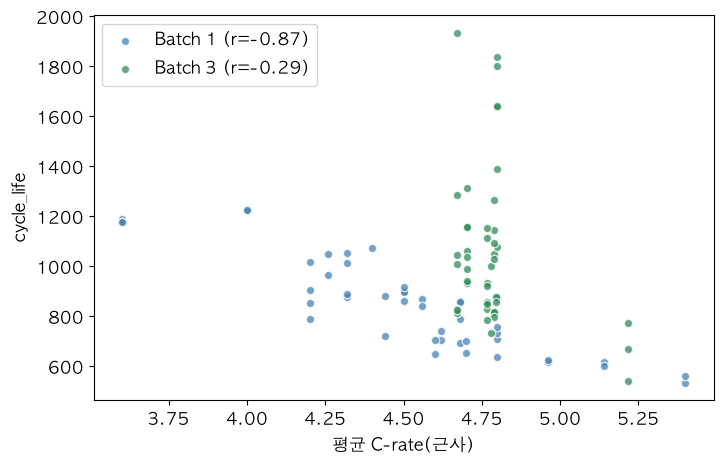

,정책수,c_avg_평균,c_avg_최소,c_avg_최대
batch,,,,
1,23,4.53,3.60,5.40
3,8,4.78,4.67,5.22


Batch 1·3 공통 정책 수: 0
Batch 3 정책별 평균 수명:


,mean,count
policy,,
4.8C(80%)-4.8C-newstructure,1564.0,6
5C(67%)-4C-newstructure,1106.0,7
5.3C(54%)-4C-newstructure,1074.0,8
5.6C(19%)-4.6C-newstructure,1001.0,8
5.6C(36%)-4.3C-newstructure,931.0,8
5.9C(15%)-4.6C-newstructure,867.0,2
5.9C(60%)-3.1C-newstructure,866.0,2
3.7C(31%)-5.9C-newstructure,660.0,3



Batch 3: r=-0.29, Spearman=-0.04 | 가장 빠른 정책(3.7C(31%)-5.9C, 3셀) 제외 41셀 r=0.09
c_avg 4.67~4.80 (41셀)의 수명 범위: 731~1935 | newstructure 정책 비율: 100%
같은 정책 4.8C(80%)-4.8C의 배치별 평균 수명 (newstructure 구분):


count    mean
batch newstructure               
1     False             2   753.0
2     False             5   484.0
      True              3   872.0
3     True              6  1564.0

In [26]:
T = 3
fig, ax = plt.subplots(figsize=(8, 5))
for n in (1, T):
    s = cb[cb.batch == n].dropna(subset=['c_avg']); ax.scatter(s.c_avg, s.cycle_life, c=col[n], alpha=.75, edgecolors='white', label=f'Batch {n} (r={s.c_avg.corr(s.cycle_life):.2f})')
ax.set_xlabel('평균 C-rate(근사)'); ax.set_ylabel('cycle_life'); ax.legend(); plt.show()
display(cb[cb.batch.isin([1, T])].groupby('batch').agg(정책수=('policy', 'nunique'), c_avg_평균=('c_avg', 'mean'), c_avg_최소=('c_avg', 'min'), c_avg_최대=('c_avg', 'max')).round(2))
print(f'Batch 1·{T} 공통 정책 수:', len(set(cb[cb.batch == 1].policy) & set(cb[cb.batch == T].policy)))
print(f'Batch {T} 정책별 평균 수명:'); display(cb[cb.batch == T].groupby('policy').cycle_life.agg(['mean', 'count']).sort_values('mean', ascending=False).round(0))
from scipy.stats import spearmanr
s3 = cb[cb.batch == T].dropna(subset=['c_avg']); x_ = s3[s3.c_avg < 5]; m_ = s3[s3.c_avg.between(4.6, 4.85)]
print(f"\nBatch {T}: r={s3.c_avg.corr(s3.cycle_life):.2f}, Spearman={spearmanr(s3.c_avg, s3.cycle_life)[0]:.2f} | 가장 빠른 정책(3.7C(31%)-5.9C, {len(s3)-len(x_)}셀) 제외 {len(x_)}셀 r={x_.c_avg.corr(x_.cycle_life):.2f}")
print(f"c_avg 4.67~4.80 ({len(m_)}셀)의 수명 범위: {m_.cycle_life.min():.0f}~{m_.cycle_life.max():.0f} | newstructure 정책 비율: {s3.policy.str.contains('newstructure').mean():.0%}")
print('같은 정책 4.8C(80%)-4.8C의 배치별 평균 수명 (newstructure 구분):'); display(cb[cb.policy.str.startswith('4.8C(80%)-4.8C')].assign(newstructure=lambda x: x.policy.str.contains('newstructure')).groupby(['batch', 'newstructure']).cycle_life.agg(['count', 'mean']).round(0))


**관찰**
- Batch 3 정책은 8종이고 **Batch 1과 겹치는 정책이 0개**. 44셀 전부 `newstructure` 정책. 평균 C-rate는 4.67~5.22로 좁고, 수명과의 상관은 r=−0.29 (Spearman −0.04).
- 이 상관은 가장 빠른 정책 `3.7C(31%)-5.9C`(3셀, 평균 C-rate 5.22, 평균 수명 660) **한 정책이 만든 것**: 이 3셀을 빼면 r=+0.09.
- 나머지 41셀(평균 C-rate 4.67~4.80)에서는 수명이 731~1,935로 크게 갈림.
- 같은 이름의 `4.8C(80%)-4.8C` 정책이 배치마다 수명이 다름: Batch 1 753 / Batch 2 484 (newstructure 872) / Batch 3(newstructure) 1,564. **같은 `newstructure` 표기끼리도 Batch 2(872)와 Batch 3(1,564)가 약 1.8배 차이**.

**시사점**
- 충전 정책 이름·평균 C-rate로는 수명을 설명할 수 없음 → **정책 feature는 모델에서 제외**하고 셀 신호(ΔQ 등) 중심으로 설계.
- `newstructure`가 무엇인지(셀 구조 변경 등)는 가설 단계 — 보고서에는 '가설'로 표기. 같은 표기라도 배치마다 수명이 달라 `newstructure` 하나로도 수명이 설명되지 않음.


## [B3] Q5. 상관관계

In [27]:
T = 3
display(corr_b[['Batch 1', f'Batch {T}']].assign(차이=lambda x: x[f'Batch {T}'] - x['Batch 1']).round(2).style.background_gradient(cmap='RdBu_r', vmin=-1, vmax=1, subset=['Batch 1', f'Batch {T}']))

,Batch 1,Batch 3,차이
QD_mean,0.190000,0.220000,0.020000
IR_mean,0.180000,0.190000,0.010000
Tavg_mean,-0.480000,-0.020000,0.460000
chargetime_mean,0.580000,0.640000,0.060000
QD_slope,0.200000,0.330000,0.130000
dQ_log_var,-0.890000,-0.700000,0.180000
dQ_log_min,-0.870000,-0.700000,0.170000


**관찰**
- `dQ_log_var` −0.70, `dQ_log_min` −0.70 (Batch 1 −0.89, −0.87)으로 약해졌지만 **부호는 유지**하고 B3에서도 상관이 가장 큼. 그다음이 `chargetime_mean` +0.64(Batch 1 +0.58) — dQ와 차이가 크지 않음.
- Tavg_mean은 −0.02 (Batch 1 −0.48)로 관계가 사라짐. QD_mean(+0.22)·IR_mean(+0.19)은 약한 양으로 유지되지만 Batch 3(44셀)의 유의 기준 |r|≈0.30에 못 미침.
- QD_slope는 +0.33(Batch 1 +0.20)으로 오히려 커짐. Batch 2에서는 −0.44였으므로 **QD_slope 부호가 Batch 1(+) → Batch 2(−) → Batch 3(+)로 배치마다 바뀜.**

**시사점**
- 세 배치에서 부호가 일관된 것은 `dQ_log_var`뿐이고 크기도 가장 안정적(−0.89/−0.90/−0.70). `chargetime_mean`은 부호는 같지만 Batch 2에서 +0.09로 사라졌으므로(+0.58/+0.09/+0.64) 크기가 불안정 → **제외**.
- Tavg는 Batch 2에서 부호 반전, Batch 3에서 소실 → **배치에 따라 불안정, 제외**.
- Batch 3에서 dQ 상관이 약해지는 것은 주로 수명 1,600 이상 초장수명 5셀 때문(Q3: 이 5셀 제외 시 −0.82). 모델 일반화 한계로 보고서에 명시.


## 종합 → 모델 전략

### 한 줄 결론
**초기 100 사이클의 ΔQ(V) 곡선 깊이(`dQ_log_var`)가 배치가 바뀌어도 수명을 가장 안정적으로 설명하는 신호다. 이를 중심으로 `cycle_life`를 예측하는 회귀 모델을 만든다.** 충전 정책·온도·초기 용량 계열은 Batch 1에서 상관이 있어도 배치마다 관계가 달라져 핵심 feature로 쓰지 않는다.

### 문항별 결과

| 문항 | 확인한 내용 (핵심 숫자) | 시사점 | 모델링 전략 |
|---|---|---|---|
| **Q1 수명 분포** | Batch 1: 평균 845 (534~1227), 단수명(<500) 0개 / Batch 2: 평균 566 (392~1186), 72%가 <500, 두 덩어리(392~514 30셀 / 777~1186 9셀), KS p=6.6e-13 / Batch 3: 평균 1060 (541~1935), 52%가 >1000 | 배치마다 수명 분포가 크게 다름. 550 기준 단수명 비율이 Batch 1 2%, Batch 2 77%, Batch 3 2%로 배치마다 다름 → 분류는 불안정. Batch 2는 학습 범위 아래, Batch 3는 위 | **회귀 선택.** 학습 범위 밖을 예측해야 하므로 외삽이 되는 선형 계열 우선. 지표는 MAPE |
| **Q2 열화 곡선** | 초기 용량은 모든 셀이 거의 동일(1.06~1.10Ah) / 열화는 후반에 가속(비선형) / knee는 수명의 약 71% 지점(배치 간 0.71~0.76) / Batch 2는 초기에 용량이 오르는 셀 다수 | 초기 QD만으로는 셀 구분 불가, 초기 용량 거동은 배치마다 다름. knee는 예측 시점(100 사이클)에 알 수 없음 | 초기 QD 평균·기울기는 쓰지 않음. **knee는 feature로 쓰지 않고 EDA 설명용**으로만 사용 |
| **Q3 ΔQ(V)** | 단수명 셀 곡선이 깊고(약 −0.06Ah) 장수명은 얕음(약 −0.01Ah) / `dQ_log_var`와 수명의 상관 Batch 1 −0.89, Batch 2 −0.90, Batch 3 −0.70 | 곡선 깊이 = 초기 열화 속도 → 100 사이클 안에 수명 신호가 있고 배치 간에 유지됨 (Batch 3는 약해짐, 주원인은 초장수명 5셀) | **핵심 feature = `dQ_log_var`.** `dQ_log_min`과는 r=0.99라 하나만 사용. Batch 3는 수명 1,600 이상 초장수명 5셀이 추세선 위에 있어 상관이 약해짐(한계로 기록) |
| **Q4 충전 조건** | Batch 1: 평균 C-rate와 수명 r=−0.87 / Batch 2 −0.25, Batch 3 −0.29 (가장 빠른 정책 3셀을 빼면 +0.09) / 같은 정책이 `newstructure` 유무에 따라 수명 약 2배 (4.8C(80%)-4.8C: 484 vs 872), 같은 `newstructure`끼리도 Batch 2 872 vs Batch 3 1,564 / Batch 1·2 공통 정책 2개는 Batch 2에서 35~45% 짧음(753 → 484, 744 → 400) | 충전 정책은 Batch 1에서만 설명력이 있고 배치 간 일반화가 안 됨. 같은 정책·같은 `newstructure` 표기라도 배치마다 수명이 달라, 정책 이름이나 구조 표기가 아니라 셀에서 측정한 신호가 필요 (`newstructure`의 정체는 가설) | **충전 정책 feature는 제외** (보조로도 쓰지 않음). 셀에서 측정한 신호 중심으로 설계 |
| **Q5 상관관계** | 수명과의 상관: dQ_log_var −0.89 > 평균 C-rate −0.87 > chargetime +0.58 > Tavg −0.48 / 초기 용량·IR은 약함(≤0.2) / 다중공선성: Tavg–Tmax 0.96, dQ_var–dQ_min 0.99, dQ_var–C-rate 0.92 / 온도는 부호가 바뀌고(−0.48 → +0.42), 충전시간은 +0.58 → +0.09로 사라지며, 초기 용량·IR은 Batch 1에서도 약했음 | ΔQ 계열만 배치 간 안정. feature끼리 겹치므로 많이 넣을수록 좋지 않음 | feature 수를 최소화(`dQ_log_var` 중심 + 소수 보조 후보). **규제 선형 모델(Elastic Net)은 feature를 늘릴 때 유리** |

### Feature Engineering (선별 결과)

선별 근거는 **Batch 1**의 상관·교차검증만 사용. Batch 2·3는 "배치가 바뀌어도 유지되는지" 점검용.

| Feature | 계산 | 수명과 상관 (B1 / B2 / B3) | 판단 | 이유 |
|---|---|---|---|---|
| **`dQ_log_var`** | log10(\|Var(Q100(V) − Q10(V))\|) | −0.89 / −0.90 / −0.70 | ✅ **사용 (핵심)** | 초기 열화 속도를 직접 반영, 3개 배치 모두 같은 부호·큰 크기 |
| `dQ_log_min` | log10(\|min(ΔQ(V))\|) | −0.87 / −0.89 / −0.70 | ❌ 제외 (대체 가능) | `dQ_log_var`와 r=0.99 → 정보 중복, 하나만 사용 |
| 평균 C-rate (`c_avg`) | c1×전환SOC + c2×(1−전환SOC) 근사 | −0.87 / −0.25 / −0.29 | ❌ 제외 (보조 후보) | B1에서만 강함, 배치 간 일반화 안 됨. `dQ_log_var`와 r=0.92로 겹침 |
| `chargetime_mean` | 초기 100 사이클 평균 충전 시간 | +0.58 / +0.09 / +0.64 | ❌ 제외 | 충전 정책과 같은 정보, 배치마다 크기가 크게 달라짐 |
| `Tavg_mean` | 초기 100 사이클 평균 온도 | −0.48 / +0.42 / −0.02 | ❌ 제외 | 배치마다 부호가 바뀜, `Tmax`와 r=0.96 |
| `QD_mean`, `QD_slope` | 초기 방전 용량 평균·기울기 | QD_mean +0.19 / −0.33 / +0.22, QD_slope +0.20 / −0.44 / +0.33 | ❌ 제외 | B1에서 약하고(유의하지 않음) 배치마다 부호가 바뀜. 초기 용량은 셀 간 거의 동일(1.06~1.10Ah), B2는 초기에 용량이 오르는 셀 존재 |
| `IR_mean` | 초기 100 사이클 평균 내부저항 | +0.18 / −0.35 / +0.19 | ❌ 제외 | 수명 신호가 약하고 B2에서 부호가 바뀜 |
| knee | Kneedle로 찾은 꺾임 지점 | — | ❌ 제외 | 수명의 약 71% 지점이라 100 사이클 시점에는 알 수 없음 (예측에 쓰면 누수) |

- 최종 입력은 **`dQ_log_var` 1개**로 시작. 보조 feature는 Batch 1 그룹 교차검증에서 성능이 오를 때만 추가.
- Batch 3의 `dQ_log_var` 상관이 약해진 것(−0.70)은 주로 수명 1,600 이상 5셀이 추세선 위에 있기 때문(이 5셀 제외 −0.82). 양(+) 볼록 셀 8개만 빼면 −0.73으로 주원인이 아님(Spearman은 −0.80).

### Regression vs Classification (타깃 선택)

| 항목 | 내용 |
|---|---|
| **선택** | **회귀** |
| **Target Variable** | `cycle_life` (용량이 공칭의 80%에 도달하는 사이클 수). 필요하면 `log10(cycle_life)` 변환도 비교 |
| **평가 지표** | MAPE (원논문 9.1%와 비교), RMSE 보조 |

**분류를 선택하지 않은 이유 (근거는 EDA 출력)**
- 단수명 기준(550)으로 나눈 비율이 Batch 1 2%, Batch 2 77%, Batch 3 2%로 **배치마다 다름**. Batch 1에는 500 미만 셀이 0개(550 미만은 1개)라, Batch 1로 학습하는 분류 모델은 사실상 한 클래스만 보게 됨.
- 분류 경계를 어디에 두든 근거가 배치마다 달라짐(Batch 1 수명 534~1227, Batch 2 392~1186, Batch 3 541~1935).
- 회귀는 연속값 그대로 학습하므로 배치마다 분포가 달라도 같은 목표(수명 예측)를 유지함.

**회귀의 약점과 대응**
- Batch 2의 77%(30/39)는 Batch 1 최소 수명(534) 아래이고 Batch 3는 최대(1227) 위 → **학습 범위 밖 예측(외삽)** 문제. 대응: 외삽이 되는 선형 계열 우선, 트리는 비교용. 타깃 log 변환·짧은 수명 구간 가중치는 Batch 1 교차검증에서만 비교(미정).
- 수명이 짧은 셀은 같은 절대 오차라도 MAPE가 크게 나옴 → MAPE와 함께 잔차를 확인.

### 모델링 전략

| 단계 | 내용 | 근거 |
|---|---|---|
| 타깃 | `cycle_life` 회귀 (필요하면 log 변환도 비교) | Q1: 분류 기준이 배치마다 불균형 |
| 입력 | 초기 100 사이클의 `dQ_log_var` 중심 + 보조 feature 후보를 Batch 1 교차검증으로 검증 | Q3, Q5: ΔQ만 배치 간 안정 |
| 전처리 | 수명 NaN 셀 제외, 용량 스파이크는 중앙값 필터/구간 요약 | Q2: 스파이크 노이즈, 데이터 품질 |
| 후보 모델 | ① 단순 선형 회귀(`dQ_log_var` 1개, 기준선) ② Elastic Net(보조 feature를 추가할 때, 1개일 때는 선형 회귀와 거의 같음) ③ Ridge ④ Random Forest, Gradient Boosting(비선형 비교용) | feature 1개로 시작하므로 단순 선형 회귀가 기준선, feature를 늘릴 때(상관 높고 표본 46개) 규제 선형 / 트리는 학습 최소 수명(534) 아래를 예측하지 못해 Batch 2의 77%에서 오차가 클 것이라 비교용 |
| 검증 | 같은 정책 셀이 train/valid에 섞이지 않게 **셀(정책) 단위로 분리한 hold-out + 그룹 교차검증** | 정책당 셀 1~3개 → 누수 위험 |
| 최종 평가 | Batch 2로 **1회만** 평가. 원논문 MAPE 9.1%와 비교 | Batch 2는 최종 평가 전용 |
| 기대·위험 | Batch 2 수명이 학습 범위 아래라 외삽 오차로 성능이 논문보다 낮을 가능성. Batch 2의 `newstructure` 9셀(777~1186) 중 일부는 같은 dQ에서 Batch 1 추세선보다 수명이 짧아 과대예측 가능성(산점도 관찰). Gap(Valid–Test)을 배치 간 일반화 저하의 근거로 해석 | Q1, Q3 |
| 하지 않는 것 | Batch 2 결과를 보고 feature·모델 선택 / Batch 3 모델링 / knee·정책 feature 사용 | 누수 방지, 범위 제한 |

### 주의
- Batch 2는 최종 평가 전용이고, Batch 3는 이번에 **EDA에서만** 사용한다(모델링·평가 제외). Batch 3의 수명 NaN 2셀(2,200 사이클 이상 측정, EOL 미도달)은 제외되어 가장 긴 수명 셀이 빠져 있다.
- `newstructure`가 셀 구조 변경이라는 설명은 **가설**이다(확인되지 않음).
- 표본이 작아(배치당 40~46셀, 정책당 1~3셀) 상관·평균은 경향 수준으로 해석한다.
- 그 밖의 한계·고민 지점·변경 이력은 프로젝트 루트의 `NOTES.md` 참고.
